<div align="center">

# Notebook 12 — Scalogramme CWT + ResNet (ImageNet, torchvision) + WavLM Base-Plus (+ Pantagruel / résidu vocodeur en option)

# Classification multi-classes FOCH

**Fusion quadri-branche configurable — encodeurs de parole gelés + résidu vocodeur log-mel + réseau convolutif gelé sur scalogramme CWT**

![Python](https://img.shields.io/badge/Python-3.12-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.11-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)
![Vocos](https://img.shields.io/badge/Vocos-r%C3%A9sidu%20vocodeur-8A2BE2?style=flat-square)
![PyWavelets](https://img.shields.io/badge/PyWavelets-CWT%20scalogramme-1f77b4?style=flat-square)
![torchvision](https://img.shields.io/badge/torchvision-ResNet%20ImageNet-EE4C2C?style=flat-square&logo=pytorch)

</div>


## Synthèse de l'architecture quadri-branche

Ce notebook conserve intégralement le protocole d'évaluation du template (`StratifiedKFold` à 5 plis, déduplication patient, augmentation injectée dans le seul train, `FocalLoss` pondérée par pli) et n'en change que la **partie représentation** — exactement comme `10_0_foch_test_pantagruel.ipynb` et `11_0_foch_test_cwt_dinov2.ipynb` avant lui. Quatre branches, toutes activables indépendamment via le preset `BACKBONE` (Cellule 1) :

| Branche | Modèle / source | Entraînable ? | Sortie |
|---|---|---|---|
| **A — WavLM Base-Plus** | `microsoft/wavlm-base-plus`, répertoire local | **gelée** | moyenne temporelle du `last_hidden_state` → 768-d |
| **B — Pantagruel `speech-large-14K`** | dépôt local `speech-large-14K` (`trust_remote_code=True`) | **gelée** | moyenne temporelle du `last_hidden_state` → dimension **résolue à l'exécution** |
| **C — Résidu vocodeur (Vocos)** | `charactr/vocos-mel-24khz`, répertoire local, inférence CPU | **gelé** — seule la projection est apprise | 6 statistiques log-mel → `RESIDUAL_PROJ_DIM`-d après `Linear → ReLU` |
| **D — Scalogramme CWT → ResNet** *(cette variante)* | poids ImageNet torchvision (`RESNET_VARIANT`, défaut `resnet50`) | **gelée** | vecteur pooled après retrait de la tête de classification → dimension **résolue à l'exécution** |

**1 — Pourquoi un ResNet plutôt qu'un Vision Transformer pour la branche D.** `11_0_foch_test_cwt_dinov2.ipynb` explorait la même idée (scalogramme → backbone pré-entraîné sur images naturelles, gelé) avec DINOv2-Large, un Vision Transformer. Ce notebook teste le pari inverse avec un réseau **convolutif classique** : un ResNet construit sa représentation par une hiérarchie de champs récepteurs **locaux**, qui s'élargissent progressivement couche après couche (convolution + pooling), là où un ViT applique une attention **globale** dès sa première couche. Aucune des deux familles n'a de a priori de parole ou de signal audio dans son pré-entraînement — les deux sont entraînées sur ImageNet, des images naturelles. La question ouverte que ce notebook permet de trancher empiriquement : est-ce que les motifs pathologiques d'un scalogramme sont mieux captés par des textures locales (ResNet) ou par des relations spatiales à longue portée dans l'image entière (ViT) ? Aucune des deux hypothèses n'est a priori la bonne.

**2 — Pourquoi la CWT plutôt qu'un spectrogramme STFT/mel (inchangé depuis la variante ViT).** La CWT donne une résolution fréquentielle **logarithmique** — fine en basses fréquences (F0, périodicité jitter/shimmer), plus grossière en aigu — a priori mieux adaptée aux irrégularités de phonation que la résolution linéaire d'un spectrogramme STFT classique (utilisé, en domaine mel, par la branche résidu vocodeur C).

**3 — Lien avec l'approche de M. Ossonce.** Comme la variante ViT, cette branche rejoint l'esprit de l'approche décrite par M. Ossonce sur un projet PPG antérieur (signal → résidu d'un prédicteur → transformée en ondelettes → séparation détail/approximation → classifieur peu profond sur les coefficients) — un ResNet pré-entraîné remplace ici les coefficients faits main + SVM par un transfert d'apprentissage visuel convolutif, plutôt qu'attentionnel comme dans la variante DINOv2.

**4 — Pourquoi conserver les branches A/B/C à côté.** Comme dans les deux notebooks précédents, les branches ne sont pas supposées redondantes *a priori*. Le système de presets (Cellule 1) permet de les combiner ou de les isoler : `wavlm_bp_cwt_resnet` (préset par défaut de ce notebook — la combinaison explicitement demandée) jusqu'à `pantagruel_wavlm_bp_residual_cwt_resnet` (les quatre branches), en passant par des ablations solo.

**5 — Portée du fine-tuning : la tête uniquement.** Les trois encodeurs profonds (WavLM, Pantagruel, ResNet) sont **intégralement gelés**, sans exception ni dégel tardif — même contrainte que les deux notebooks précédents. Le ResNet est nettement plus léger que DINOv2-Large (~25 M paramètres pour `resnet50`, contre ~300 M), ce qui allège sensiblement le budget VRAM par rapport à `11_0_foch_test_cwt_dinov2.ipynb` sans changer la logique de gel elle-même.

> Les justifications détaillées accompagnent chaque section (Cellules 1, 4, 4c, 6, 6b, 7).


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection des branches**. Le notebook met en œuvre un **classifieur quadri-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**
<div align="center">

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Paralysie récurrentielle — pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Lésion de la muqueuse bénigne — support intermédiaire |
| `fuite glottique` | FOCH | Support le plus faible — classe minoritaire critique |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

</div>

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable des branches (`BACKBONE`)

Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding — la dimension de fusion est toujours la **somme** des dimensions des branches actives.

<div align="center">

| Preset | WavLM Base-Plus | Pantagruel | Résidu vocodeur | CWT → ResNet | Fusion |
|---|---|---|---|---|---|
| `wavlm_bp_cwt_resnet` *(défaut de ce notebook)* | ✅ 768-d | — | — | ✅ *(dim. résolue)* | somme des deux |
| `pantagruel_wavlm_bp_residual_cwt_resnet` | ✅ 768-d | ✅ | ✅ `RESIDUAL_PROJ_DIM` | ✅ | somme des quatre |
| `pantagruel_wavlm_bp_cwt_resnet` | ✅ 768-d | ✅ | — | ✅ | somme des trois |
| `cwt_resnet_solo` | — | — | — | ✅ | dim. ResNet |
| `pantagruel_wavlm_bp_residual` | ✅ 768-d | ✅ | ✅ | — | somme des trois (hérité) |
| `pantagruel_wavlm_bp` | ✅ 768-d | ✅ | — | — | somme des deux |
| `pantagruel_solo` | — | ✅ | — | — | dim. Pantagruel |
| `wavlm_bp_solo` | ✅ 768-d | — | — | — | 768-d |
| `residual_solo` | — | — | ✅ | — | `RESIDUAL_PROJ_DIM` |
| `pantagruel_residual` / `wavlm_bp_residual` | selon | selon | ✅ | — | somme |

</div>

`wavlm_bp_cwt_resnet` est le préset **par défaut** de ce notebook — la combinaison explicitement demandée (WavLM Base-Plus + scalogramme CWT → ResNet). Les presets hérités de `10_0_foch_test_pantagruel.ipynb`/`11_0_foch_test_cwt_dinov2.ipynb` (Pantagruel, résidu vocodeur) restent tous disponibles pour composer des ablations plus larges, y compris le preset complet à quatre branches.

> 🔌 **Chargement local pour les branches HuggingFace, cache local pour la branche torchvision.** WavLM, Pantagruel et Vocos sont chargés depuis des répertoires locaux avec `local_files_only=True` (aucun accès à `huggingface.co`). La branche ResNet, elle, passe par **torchvision**, pas par HuggingFace : ses poids ImageNet sont mis en cache sous `TORCH_HOME` (Cellule 1) au premier téléchargement. `download.pytorch.org` est un domaine **distinct** de `huggingface.co` — non couvert par le même blocage réseau a priori, mais **non vérifié** sur cette machine. Si le téléchargement échoue, déposer manuellement le `.pth` correspondant dans `{TORCH_HOME}/hub/checkpoints/` fait que torchvision le retrouve sans appel réseau (cf. Cellule 6 pour le message d'erreur explicite en cas d'échec).

> 📦 **Dépendances ajoutées par ce notebook.** `pywt` (PyWavelets) pour la CWT, `matplotlib` pour la colormap du scalogramme, `torchvision` pour le ResNet (généralement déjà présent aux côtés de `torch`).

### Dimension d'embedding de Pantagruel — résolue, jamais supposée

⚠️ **Piège de configuration.** Le `config.json` de Pantagruel expose **deux** attributs de dimension contradictoires :

- `hidden_size = 768` — valeur héritée par défaut de `PretrainedConfig`, **jamais utilisée** par le graphe du modèle ;
- `embed_dim = 1024` — dimension réellement employée par toutes les couches (`modeling_pantagruel_uni.py` construit chaque bloc à partir de `config.embed_dim`).

Lire `config.hidden_size`, réflexe habituel avec les modèles HuggingFace, donnerait ici une dimension de fusion **fausse de 256**. La Cellule 1 résout donc la dimension via `_resolve_pantagruel_dim()` (priorité à `embed_dim`) et **signale explicitement** la divergence ; la Cellule 6 la **revérifie sur une passe avant réelle**.

### Dimension et taille d'image ResNet — même discipline, résolution différente

`RESNET_EMB_DIM` et `RESNET_IMG_SIZE` ne sont **pas** écrites en dur — même philosophie que la dimension Pantagruel, mécanique différente : torchvision associe à chaque jeu de poids un objet `weights.transforms()` qui expose le `crop_size`, la moyenne et l'écart-type utilisés pour PRODUIRE ce checkpoint. `RESNET_EMB_DIM` est lue depuis `.fc.in_features` de l'architecture (`weights=None`, aucun téléchargement) ; la Cellule 6 la revérifie sur une passe avant réelle avec les poids ImageNet chargés cette fois, exactement comme pour Pantagruel.

### Branche résidu vocodeur

`RESIDUAL_FEATURES` est une **liste fixe** de 6 statistiques dérivées du résidu log-mel Vocos (Cellule 4) : énergie globale, moyenne `|résidu|` par tiers de bandes mel (grave/médian/aigu), platitude spectrale, entropie temporelle. Elles sont projetées par un `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU`.

### Branche scalogramme CWT → ResNet

`CWT_WAVELET` (Morlet complexe), `CWT_FREQ_MIN`/`CWT_FREQ_MAX` (bande de fréquences log-espacée) et `CWT_N_SCALES` pilotent le calcul du scalogramme (Cellule 4, inchangé depuis la variante ViT) ; `CWT_COLORMAP` pilote sa conversion en image RGB. `RESNET_VARIANT` (`resnet18` / `resnet34` / `resnet50`, défaut `resnet50`) pilote l'architecture ET les poids ImageNet associés — le changer ne touche aucune autre cellule, tout ce qui en dépend étant résolu à l'exécution. Comme pour la branche résidu vocodeur, **aucune de ces valeurs n'est apprise** ; contrairement à elle, **aucune n'est non plus normalisée au niveau du pli** : la normalisation finale de l'image applique les statistiques du **checkpoint ImageNet choisi**, pas des statistiques dérivées de nos données.

### Budget mémoire

Les trois encodeurs profonds étant gelés et exécutés sous `torch.no_grad()`, **aucune activation intermédiaire n'est conservée**. Le ResNet (`resnet50` : ~25 M paramètres) est bien plus léger que la variante DINOv2-Large (~300 M) du notebook précédent — le budget VRAM de ce notebook devrait donc être sensiblement plus confortable. La **sonde VRAM (Cellule 6b)** reste à relancer après tout changement de preset ou de `RESNET_VARIANT`. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os

# ── Mode strictement HORS LIGNE (Hugging Face) ───────────────────────────────
# Cette machine n'a pas accès à huggingface.co. Ces variables DOIVENT être
# posées AVANT l'import de `transformers` : la bibliothèque les lit au moment
# de son initialisation. Tous les modèles HuggingFace sont ensuite chargés
# depuis des répertoires locaux avec local_files_only=True.
os.environ['HF_HUB_OFFLINE']      = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

# ── Cache local des poids torchvision (ResNet, branche D) ────────────────────
# torchvision télécharge les poids ImageNet depuis download.pytorch.org — un
# domaine DISTINCT de huggingface.co, potentiellement non couvert par le même
# blocage réseau, mais NON vérifié sur cette machine. TORCH_HOME fixe
# l'emplacement du cache avant le premier appel torchvision : si le
# téléchargement automatique échoue, déposer manuellement le fichier .pth
# correspondant dans `{TORCH_HOME}/hub/checkpoints/` fait que torchvision le
# retrouve sans aucun appel réseau au prochain essai — même logique de
# contournement que le `git clone` + `git lfs pull` utilisé pour Vocos.
TORCH_HOME = r'C:/Users/AdminIA/Documents/models/.torch_cache'
os.environ['TORCH_HOME'] = TORCH_HOME
os.makedirs(TORCH_HOME, exist_ok=True)

import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:\Users\AdminIA\Desktop\Classif_Aug\.df\.good_df\orl_df_vowel_master_updated_20260803.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
# Chaque manifeste ne contient qu'un seul type d'augmentation (colonne `aug_type`
# du CSV, vérifié) :
#   'signal' → SpecAugment sur STFT linéaire (specaug.ipynb) — même patient
#   'vc'     → Seed-VC (voice conversion) — timbre d'un AUTRE patient, même classe
# AUG_TYPES_ENABLED sélectionne lesquels sont effectivement injectés en train
# (Cellule 5). Retirer un type ici retire tout son volume du pool augmenté sans
# toucher aux manifestes ni aux fichiers .wav sur disque.
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = {
    'signal': os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    'vc':     os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
}
AUG_TYPES_ENABLED = {'signal', 'vc'}   # sous-ensemble de AUG_MANIFESTS — set() = pas d'augmentation

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DES BRANCHES  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau QUADRI-BRANCHE. Chaque branche est indépendante :
#   • WavLM Base-Plus (gelé)  — détail acoustique microscopique, anglais,
#     objectif de pré-entraînement « denoising / speaker mixing » ;
#   • Pantagruel speech-large-14K (gelé) — encodeur data2vec-2.0 pré-entraîné
#     sur ~14 000 h de parole FRANÇAISE, apparié à la langue du corpus FOCH ;
#   • Résidu vocodeur (Vocos, gelé) — écart, en domaine LOG-MEL, entre un
#     enregistrement et sa propre resynthèse par un vocodeur neuronal
#     pré-entraîné ; résumé par 6 statistiques et projeté vers
#     RESIDUAL_PROJ_DIM ;
#   • Scalogramme CWT → ResNet (gelé) — la forme d'onde est transformée en
#     image temps-fréquence (transformée en ondelettes continue, ondelette de
#     Morlet complexe) puis analysée par un RÉSEAU CONVOLUTIF classique
#     (ResNet, poids ImageNet, torchvision), gelé. Remplace la variante
#     Vision Transformer (DINOv2-Large) explorée dans
#     `11_0_foch_test_cwt_dinov2.ipynb` — même idée de branche (image de
#     scalogramme → backbone pré-entraîné sur images naturelles, gelé), pari
#     architectural différent (convolutif/local plutôt qu'attention/global).
#     Cf. Cellule 4 pour le calcul du scalogramme et Cellule 6 pour le modèle.
#
# On sélectionne un preset unique ; le Dataset, le modèle et la boucle
# d'entraînement s'adaptent automatiquement aux branches actives.
#
#   'wavlm_bp_cwt_resnet'                     → WavLM-BP + CWT→ResNet   [DÉFAUT]
#   'pantagruel_wavlm_bp_residual_cwt_resnet' → les QUATRE branches
#   'pantagruel_wavlm_bp_cwt_resnet'          → WavLM-BP + Pantagruel + CWT→ResNet
#   'cwt_resnet_solo'                         → CWT→ResNet seul          (ablation)
#   'pantagruel_wavlm_bp_residual'            → WavLM-BP + Pantagruel + résidu (sans CWT-CNN)
#   'pantagruel_wavlm_bp'                     → WavLM-BP + Pantagruel (sans résidu ni CWT-CNN)
#   'pantagruel_solo'                         → Pantagruel seul          (ablation)
#   'wavlm_bp_solo'                           → WavLM Base-Plus seul     (ablation)
#   'residual_solo'                           → résidu vocodeur seul     (ablation / référence)
#   'pantagruel_residual' / 'wavlm_bp_residual' → ablations croisées à deux branches
#
BACKBONE = 'pantagruel_wavlm_bp_cwt_resnet'

_BACKBONE_PRESETS = {
    'wavlm_bp_cwt_resnet':                     {'wavlm': 'base_plus', 'pantagruel': False, 'residual': False, 'cwt_cnn': True},
    'pantagruel_wavlm_bp_residual_cwt_resnet': {'wavlm': 'base_plus', 'pantagruel': True,  'residual': True,  'cwt_cnn': True},
    'pantagruel_wavlm_bp_cwt_resnet':          {'wavlm': 'base_plus', 'pantagruel': True,  'residual': False, 'cwt_cnn': True},
    'cwt_resnet_solo':                         {'wavlm': None,        'pantagruel': False, 'residual': False, 'cwt_cnn': True},
    'pantagruel_wavlm_bp_residual':            {'wavlm': 'base_plus', 'pantagruel': True,  'residual': True,  'cwt_cnn': False},
    'pantagruel_wavlm_bp':                     {'wavlm': 'base_plus', 'pantagruel': True,  'residual': False, 'cwt_cnn': False},
    'pantagruel_solo':                         {'wavlm': None,        'pantagruel': True,  'residual': False, 'cwt_cnn': False},
    'wavlm_bp_solo':                           {'wavlm': 'base_plus', 'pantagruel': False, 'residual': False, 'cwt_cnn': False},
    'residual_solo':                           {'wavlm': None,        'pantagruel': False, 'residual': True,  'cwt_cnn': False},
    'pantagruel_residual':                     {'wavlm': None,        'pantagruel': True,  'residual': True,  'cwt_cnn': False},
    'wavlm_bp_residual':                       {'wavlm': 'base_plus', 'pantagruel': False, 'residual': True,  'cwt_cnn': False},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
_preset        = _BACKBONE_PRESETS[BACKBONE]
WAVLM_VARIANT  = _preset['wavlm']         # 'base_plus' | 'base' | 'large' | None
USE_PANTAGRUEL = _preset['pantagruel']    # bool
USE_RESIDUAL   = _preset['residual']      # bool
USE_CWT_CNN    = _preset['cwt_cnn']       # bool

# ── Chemins locaux des backbones ─────────────────────────────────────────────
# ATTENTION : 'base_plus' (microsoft/wavlm-base-plus) est un CHECKPOINT DISTINCT
# de 'base' (microsoft/wavlm-base) — même architecture 12×768, poids différents
# (pré-entraînement 94 kh vs 960 h). Les trois répertoires coexistent sur disque ;
# seul 'base_plus' est référencé par les presets de ce notebook.
WAVLM_DIRS = {
    'base':      r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'base_plus': r'C:/Users/AdminIA/Documents/models/wavlm-base-plus',
    'large':     r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
PANTAGRUEL_DIR = r'C:/Users/AdminIA/Desktop/Classif_Aug/speech-large-14K'

WAVLM_DIR     = WAVLM_DIRS.get(WAVLM_VARIANT)      # None si la branche est inactive
WAVLM_EMB_DIM = {'base': 768, 'base_plus': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]

if WAVLM_VARIANT is not None:
    assert os.path.isdir(WAVLM_DIR), f'Répertoire WavLM introuvable : {WAVLM_DIR}'
if USE_PANTAGRUEL:
    assert os.path.isdir(PANTAGRUEL_DIR), f'Répertoire Pantagruel introuvable : {PANTAGRUEL_DIR}'
    # Le code de modélisation distant doit être PRÉSENT localement : ce checkpoint
    # provient de Zenodo, pas du Hub, et rien ne peut être téléchargé ici.
    _pant_required = ['config.json', 'configuration_pantagruel_uni.py', 'modeling_pantagruel_uni.py']
    _pant_missing  = [f for f in _pant_required if not os.path.isfile(os.path.join(PANTAGRUEL_DIR, f))]
    assert not _pant_missing, (
        f'Code distant Pantagruel incomplet dans {PANTAGRUEL_DIR} : {_pant_missing} manquant(s). '
        "trust_remote_code=True ne peut PAS les récupérer (accès Hub coupé)."
    )

# ── Dimension d'embedding de Pantagruel — RÉSOLUE, jamais supposée ───────────
# Le config.json expose hidden_size=768 (valeur héritée par défaut de
# PretrainedConfig, INUTILISÉE par le graphe) et embed_dim=1024 (dimension
# réellement construite par modeling_pantagruel_uni.py). Lire hidden_size
# donnerait une dimension de fusion fausse de 256 → on privilégie embed_dim et
# on signale toute divergence. La Cellule 6 revérifie sur une passe avant réelle.
def _resolve_pantagruel_dim(cfg):
    """Renvoie (dim, source, message) — dimension d'embedding réelle de Pantagruel."""
    embed  = getattr(cfg, 'embed_dim', None)
    hidden = getattr(cfg, 'hidden_size', None)
    if embed is None:
        return hidden, 'hidden_size', 'embed_dim absent — repli sur hidden_size.'
    msg = ''
    if hidden is not None and hidden != embed:
        msg = (f'divergence config : hidden_size={hidden} (hérité, ignoré par le modèle) '
               f'≠ embed_dim={embed} (utilisé) → embed_dim retenu.')
    return embed, 'embed_dim', msg


PANTAGRUEL_EMB_DIM  = 0
_pant_dim_msg       = ''
if USE_PANTAGRUEL:
    from transformers import AutoConfig
    # Charge la CONFIG seule (aucun poids lu) : suffisant pour dimensionner la fusion.
    _pant_cfg = AutoConfig.from_pretrained(
        PANTAGRUEL_DIR, trust_remote_code=True, local_files_only=True)
    PANTAGRUEL_EMB_DIM, _pant_dim_src, _pant_dim_msg = _resolve_pantagruel_dim(_pant_cfg)

# ── Branche résidu vocodeur (Vocos, log-mel, gelé) ───────────────────────────
# Remplace la branche bioacoustique Praat (jitter/shimmer/HNR/CPPS) : au lieu de
# descripteurs cliniques explicites, on compare un enregistrement à sa propre
# resynthèse par un vocodeur neuronal PRÉ-ENTRAÎNÉ ET GELÉ (Vocos, jamais
# fine-tuné, inférence CPU) — l'écart mesure ce que le vocodeur ne reproduit
# pas, un signal potentiellement corrélé à l'irrégularité pathologique de la
# phonation.
#
# Comparaison faite en domaine LOG-MEL (représentation native du vocodeur, SANS
# phase) plutôt qu'en forme d'onde brute : vocoder_residual_exploration.ipynb
# (Section 5) a mesuré, sur de vrais /a/ FOCH/SVD, un résidu temporel
# e(t) = x(t) - x̂(t) dont le RMS est SUPÉRIEUR à celui du signal original sur
# tous les groupes testés (ratio ~1.1-1.5) — pas un « petit signal d'erreur »
# exploitable tel quel, mais un résidu dominé par un désaccord de PHASE (Vocos
# est optimisé sur une perte spectrale, pas sur une reconstruction de phase
# échantillon-exacte). La phase n'existe simplement pas en domaine mel → la
# comparaison y est honnête.
VOCOS_LOCAL_DIR    = r'C:/Users/AdminIA/Documents/models/vocos-mel-24khz'
VOCOS_CONFIG_PATH  = os.path.join(VOCOS_LOCAL_DIR, 'config.yaml')
VOCOS_WEIGHTS_PATH = os.path.join(VOCOS_LOCAL_DIR, 'pytorch_model.bin')
VOCOS_SR           = 24_000   # taux natif de charactr/vocos-mel-24khz — RESOLU depuis le
                              # checkpoint chargé et revérifié en Cellule 4, jamais supposé

# QUESTION OUVERTE (reportée telle quelle, non retranchée ici — cf. journal des
# modifications) : FOCH/SVD sont natifs 16 kHz, Vocos natif 24 kHz. On
# ré-échantillonne 16→24 kHz (Cellule 4) — un ré-échantillonnage ascendant
# n'ajoute aucune information au-delà des 8 kHz de Nyquist d'origine — plutôt
# que de chercher un vocodeur pré-entraîné nativement 16 kHz. Approche reprise
# telle quelle de vocoder_residual_exploration.ipynb, non ré-évaluée ici.
if USE_RESIDUAL:
    assert os.path.isfile(VOCOS_CONFIG_PATH) and os.path.isfile(VOCOS_WEIGHTS_PATH), (
        f'Checkpoint Vocos introuvable sous {VOCOS_LOCAL_DIR} — cf. '
        f'vocoder_residual_exploration.ipynb (Section 1) pour la procédure de '
        f"récupération (git clone + git lfs pull ; hf_hub_download reste bloqué "
        f"indéfiniment sur le poids LFS sur le réseau de l'organisation)."
    )

# Précalcul en cache VS calcul à la volée — décision exposée en config plutôt
# que câblée en dur (cf. Cellule 4 pour l'implémentation et la mesure de temps
# qui la justifie). Ce notebook injecte l'augmentation via des FICHIERS
# PRÉ-GÉNÉRÉS statiques (AUG_MANIFESTS ci-dessus), PAS via une transformation de
# forme d'onde à la volée (contrairement à 9_0_foch_test_pantagruel.ipynb, qui
# applique bruit/gain/pitch/etc. par batch) : chaque enregistrement — original
# OU augmenté — correspond donc à un .wav fixe sur disque, et Vocos + le résidu
# sont entièrement déterministes par fichier. Précalculer une fois et mettre en
# cache (comme _BIO_CACHE avant lui) est donc SANS PERTE ici, pas un compromis
# — mesuré à ~30-50 ms/clip sur CPU (Cellule 4), soit un coût ponctuel de
# quelques dizaines de secondes pour tout le pool, contre des dizaines de
# minutes si recalculé à chaque epoch de chaque pli. Si une future variante de
# ce notebook réintroduit une augmentation à la volée dans __getitem__, cette
# branche devra basculer sur RESIDUAL_CACHE_ENABLED=False et calculer le résidu
# sur la forme d'onde AUGMENTÉE plutôt que sur le fichier original mis en cache.
RESIDUAL_CACHE_ENABLED = True

RESIDUAL_FEATURES = [
    'energy_mean',        # énergie globale (moyenne du carré) du résidu log-mel
    'band_low_mean',      # |résidu| moyen — tiers grave des bandes mel
    'band_mid_mean',      # |résidu| moyen — tiers médian des bandes mel
    'band_high_mean',     # |résidu| moyen — tiers aigu des bandes mel
    'spectral_flatness',  # platitude spectrale (entropie de Wiener) du profil bande-résidu
    'temporal_entropy',   # entropie temporelle normalisée de l'enveloppe d'énergie du résidu
]
N_RESIDUAL_FEATURES = len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0
RESIDUAL_PROJ_DIM   = 32   # projection avant concaténation — même dimension que l'ancienne
                           # branche bio (Cellule 6), pour une comparaison d'ablation à budget égal

# ── Branche D : scalogramme CWT → ResNet (CNN, gelé) ─────────────────────────
# Quatrième branche, indépendante des trois précédentes : au lieu d'un
# encodeur de parole 1D (WavLM/Pantagruel) ou de statistiques scalaires
# (résidu vocodeur), on transforme la forme d'onde en une IMAGE
# temps-fréquence — un scalogramme de transformée en ondelettes continue
# (CWT) — et on la fait analyser par un réseau convolutif classique
# (ResNet, poids ImageNet, torchvision), gelé comme les autres encodeurs.
#
# Remplace la variante Vision Transformer (DINOv2-Large) explorée dans
# `11_0_foch_test_cwt_dinov2.ipynb` : même position dans l'architecture
# (image de scalogramme → backbone pré-entraîné sur images naturelles, gelé,
# concaténé sans projection apprise), mais pari architectural différent — un
# ResNet construit sa représentation par une hiérarchie de champs récepteurs
# LOCAUX qui s'élargissent progressivement (convolution + pooling), alors
# qu'un ViT applique une attention GLOBALE dès sa première couche. Aucun des
# deux n'a de a priori de parole ou de signal audio dans son pré-entraînement
# (ImageNet dans les deux cas) — cf. Cellule 6 pour la discussion complète.
#
# Pourquoi la CWT plutôt qu'une STFT/mel (inchangé depuis la variante ViT) :
# résolution fréquentielle LOGARITHMIQUE (fine en basses fréquences — F0,
# périodicité jitter/shimmer — plus grossière en aigu), potentiellement mieux
# adaptée aux irrégularités de phonation que la résolution linéaire d'un
# spectrogramme STFT classique (déjà utilisé, en domaine mel, par la branche
# résidu vocodeur C).
CWT_WAVELET  = 'cmor1.5-1.0'
CWT_FREQ_MIN = 50.0
CWT_FREQ_MAX = 7500.0
CWT_N_SCALES = 128         # résolution fréquentielle de l'image, avant redimensionnement
CWT_COLORMAP = 'viridis'   # colormap perceptuellement uniforme (magnitude 1 canal → RGB)
# 224 attendu par défaut pour la plupart des checkpoints ImageNet torchvision —
# RÉSOLU sur les métadonnées réelles du checkpoint choisi ci-dessous (jamais
# supposé) ; cette constante n'est qu'un repli si la résolution échoue.
CWT_IMG_SIZE_FALLBACK = 224

# Précalcul en cache VS calcul à la volée — EXACTEMENT la même justification
# que RESIDUAL_CACHE_ENABLED ci-dessus : ce notebook n'a aucune augmentation à
# la volée (fichiers .wav fixes sur disque), donc le scalogramme d'un fichier
# donné est déterministe. La CWT (128 échelles × MAX_LEN échantillons) est plus
# coûteuse que le résidu vocodeur — mesurée en Cellule 4c — le cache est donc
# encore plus rentable ici.
SCALOGRAM_CACHE_ENABLED = True

# ── Choix du ResNet et résolution de ses métadonnées ─────────────────────────
# RESNET_VARIANT pilote à la fois l'architecture ET les poids ImageNet
# (torchvision associe un jeu de poids « officiel » par variante). resnet50
# retenu par défaut : dimension de sortie plus riche (2048-d contre 512-d pour
# 18/34) tout en restant très largement plus léger que DINOv2-Large
# (~25 M paramètres contre ~300 M) — un compromis capacité/coût raisonnable,
# pas le seul défendable. Changer RESNET_VARIANT ne touche aucune autre
# cellule : tout ce qui en dépend (dimension de fusion, taille d'image,
# normalisation) est résolu à l'exécution ci-dessous.
RESNET_VARIANT = 'resnet34'   # 'resnet18' | 'resnet34' | 'resnet50'

RESNET_EMB_DIM  = 0
RESNET_IMG_SIZE = CWT_IMG_SIZE_FALLBACK
if USE_CWT_CNN:
    import torchvision.models as tv_models

    _RESNET_BUILDERS = {
        'resnet18': (tv_models.resnet18, tv_models.ResNet18_Weights.IMAGENET1K_V1),
        'resnet34': (tv_models.resnet34, tv_models.ResNet34_Weights.IMAGENET1K_V1),
        'resnet50': (tv_models.resnet50, tv_models.ResNet50_Weights.IMAGENET1K_V2),
    }
    assert RESNET_VARIANT in _RESNET_BUILDERS, (
        f'RESNET_VARIANT inconnu : {RESNET_VARIANT} (choix : {list(_RESNET_BUILDERS)})')
    _resnet_ctor, _resnet_weights = _RESNET_BUILDERS[RESNET_VARIANT]

    # Dimension de sortie et taille d'image — RÉSOLUES depuis l'architecture et
    # les métadonnées du checkpoint choisi (torchvision expose `.fc.in_features`
    # et `weights.transforms().crop_size/mean/std`), jamais supposées à
    # 512/2048 ou 224×224 — même discipline que la dimension Pantagruel
    # ci-dessus. `weights=None` ici : lecture d'ARCHITECTURE seule, AUCUN
    # téléchargement — les poids ImageNet réels ne sont chargés qu'en
    # Cellule 6 (c'est le seul point du notebook qui touche le réseau pour
    # cette branche).
    _resnet_arch_probe = _resnet_ctor(weights=None)
    RESNET_EMB_DIM = _resnet_arch_probe.fc.in_features
    del _resnet_arch_probe

    _resnet_tf      = _resnet_weights.transforms()
    RESNET_IMG_SIZE = _resnet_tf.crop_size[0] if hasattr(_resnet_tf, 'crop_size') else CWT_IMG_SIZE_FALLBACK

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# Les quatre branches consomment la MÊME forme d'onde 16 kHz de longueur fixe ;
# seules la normalisation (WavLM/Pantagruel, cf. Cellule 4), le taux effectif
# (résidu vocodeur, ré-échantillonné à VOCOS_SR) et la représentation (image,
# pour la branche CWT-ResNet) diffèrent.
# 4 s reste la fenêtre du template : l'ancienne branche Praat imposait ce
# plancher (jitter/shimmer bruités en deçà de ~1 s) ; ni le résidu vocodeur ni
# la branche CWT-ResNet n'ont de contrainte de périodicité propre, mais on
# conserve la même fenêtre pour ne pas changer plusieurs choses à la fois.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire : les QUATRE encodeurs sont gelés et exécutés sous no_grad →
# aucune activation n'est conservée pour la rétropropagation. Le coût VRAM est
# celui d'une inférence (poids + activations d'une passe avant), pas d'un
# entraînement. La branche D (ResNet) n'ajoute AUCUN paramètre entraînable —
# gelée comme WavLM/Pantagruel, et bien plus légère que la variante DINOv2-Large
# du notebook précédent.
# Machine cible : RTX PRO 2000 portable, 8 Go. Lancer la sonde 6b après tout
# changement de BACKBONE / MAX_LEN_S / BATCH_SIZE / RESNET_VARIANT.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.1         # L2 fort : la tête est la seule partie entraînable
PATIENCE        = 6
DROPOUT         = 0.5         # tête très surparamétrée au regard de ~300 échantillons
HIDDEN_DIM      = 128         # capacité volontairement réduite (mémorisation limitée)
INPUT_DROPOUT   = 0.3         # dropout sur l'embedding fusionné, avant la 1re Linear
FOCAL_GAMMA     = 2.0         # FocalLoss : concentre le gradient sur 'fuite glottique'

# ── Portée du fine-tuning : LA TÊTE UNIQUEMENT ───────────────────────────────
# Contrainte dure de ce notebook, pas un réglage par défaut : WavLM Base-Plus,
# Pantagruel ET le ResNet de la branche D sont INTÉGRALEMENT GELÉS. ~300
# enregistrements d'entraînement ne peuvent pas remodeler des dizaines/centaines
# de millions de paramètres, même partiellement, sans surapprendre. Aucune
# logique de dégel progressif (UNFREEZE_*) n'existe dans ce notebook : elle a
# été RETIRÉE et non désactivée, pour que le code décrive exactement ce qu'il
# fait. Les branches profondes tournent en eval() + no_grad() (cf. Cellule 6).

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:  _dims.append((f'WavLM-{WAVLM_VARIANT}', WAVLM_EMB_DIM))
if USE_PANTAGRUEL: _dims.append(('Pantagruel-14K', PANTAGRUEL_EMB_DIM))
if USE_RESIDUAL:   _dims.append((f'Résidu-Vocos×{N_RESIDUAL_FEATURES}→proj', RESIDUAL_PROJ_DIM))
if USE_CWT_CNN:    _dims.append((f'CWT→{RESNET_VARIANT} ({RESNET_IMG_SIZE}px)', RESNET_EMB_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)
assert FUSION_DIM_EXPECTED > 0, 'Aucune branche active — vérifier le preset BACKBONE.'

print('Configuration chargée.')
print(f'  Preset          : {BACKBONE}  (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, '
      f'residual={USE_RESIDUAL}, cwt_cnn={USE_CWT_CNN})')
print(f'  Classes ({NUM_LABELS})     : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch. à {TARGET_SR} Hz)')
if WAVLM_VARIANT:
    print(f'  WavLM           : {WAVLM_VARIANT} — {WAVLM_EMB_DIM}-d, GELÉ ← {WAVLM_DIR}')
if USE_PANTAGRUEL:
    print(f'  Pantagruel      : {PANTAGRUEL_EMB_DIM}-d (source config : {_pant_dim_src}), GELÉ ← {PANTAGRUEL_DIR}')
    if _pant_dim_msg:
        print(f'    ⚠  {_pant_dim_msg}')
    print( '    → dimension revérifiée sur passe avant réelle en Cellule 6.')
if USE_RESIDUAL:
    print(f'  Résidu vocodeur : {N_RESIDUAL_FEATURES} descripteurs {RESIDUAL_FEATURES} → projection {RESIDUAL_PROJ_DIM}-d (entraînable)')
    print(f'    ← Vocos gelé (charactr/vocos-mel-24khz) ← {VOCOS_LOCAL_DIR} — cache {"activé" if RESIDUAL_CACHE_ENABLED else "désactivé"}')
if USE_CWT_CNN:
    print(f'  CWT → {RESNET_VARIANT} : ondelette {CWT_WAVELET}, {CWT_N_SCALES} échelles, {CWT_FREQ_MIN:.0f}-{CWT_FREQ_MAX:.0f} Hz '
          f'→ image {RESNET_IMG_SIZE}×{RESNET_IMG_SIZE} → {RESNET_EMB_DIM}-d (pooled), GELÉ (poids ImageNet torchvision)')
    print(f'    → dimension revérifiée sur passe avant réelle en Cellule 6 ; cache {"activé" if SCALOGRAM_CACHE_ENABLED else "désactivé"}')
    print(f'    → cache poids torchvision : {TORCH_HOME}')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  Fine-tuning     : tête de fusion + projection résidu UNIQUEMENT (encodeurs gelés, aucun dégel)')
print(f'  Device          : {device}')


FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset          : pantagruel_wavlm_bp_cwt_resnet  (wavlm=base_plus, pantagruel=True, residual=False, cwt_cnn=True)
  Classes (4)     : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch. à 16000 Hz)
  WavLM           : base_plus — 768-d, GELÉ ← C:/Users/AdminIA/Documents/models/wavlm-base-plus
  Pantagruel      : 1024-d (source config : embed_dim), GELÉ ← C:/Users/AdminIA/Desktop/Classif_Aug/speech-large-14K
    ⚠  divergence config : hidden_size=768 (hérité, ignoré par le modèle) ≠ embed_dim=1024 (utilisé) → embed_dim retenu.
    → dimension revérifiée sur passe avant réelle en Cellule 6.
  CWT → resnet34 : ondelette cmor1.5-1.0, 128 échelles, 50-7500 Hz → image 224×224 → 512-d (pooled), GELÉ (poids ImageNet torchvision)
    → dimen

## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  311 lignes
Lignes pathologiques retenues :  213  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (48 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  77
LMB                 62
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  77
1      LMB                 62
2      fuite glottique     26
3      Healthy            100


## 4. Processors et `Dataset` quadri-branche

Le `Dataset` encapsule toute la chaîne de prétraitement et produit, pour chaque enregistrement, les **quatre entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM Base-Plus)** — `Wav2Vec2FeatureExtractor` du répertoire `wavlm-base-plus` → `input_values` ;
3. **Branche B (Pantagruel)** — `Wav2Vec2FeatureExtractor` du répertoire Pantagruel → `pant_values` ;
4. **Branche C (résidu vocodeur)** — écart log-mel entre l'enregistrement et sa resynthèse par Vocos (gelé, CPU) → vecteur `residual` de `N_RESIDUAL_FEATURES` valeurs (cf. Cellule 4b) ;
5. **Branche D (scalogramme CWT → ResNet)** — la même forme d'onde est transformée en scalogramme CWT, converti en image RGB puis normalisé pour le checkpoint ResNet choisi → tenseur `scalogram` de forme `(3, RESNET_IMG_SIZE, RESNET_IMG_SIZE)` (cf. Cellule 4c).

> ⚠️ **Deux normalisations distinctes pour les encodeurs de parole, pas une.** `wavlm-base-plus` déclare `do_normalize=false`, Pantagruel `do_normalize=true`. Le Dataset instancie donc **un extracteur par branche**.

### Branche résidu vocodeur — robustesse, cache et coût

Le calcul (mel → resynthèse → mel → résidu → 6 statistiques) tourne entièrement en **CPU, inférence seule**, enveloppé dans un **unique bloc `try/except`**.

> ⚡ **Cache (`RESIDUAL_CACHE_ENABLED`, Cellule 1)** — le résidu vocodeur est **déterministe par fichier** : mémorisé dans `_RESIDUAL_CACHE` au premier calcul, mesuré à ~30-50 ms/clip sur CPU.

### Branche scalogramme CWT → ResNet — pipeline, cache et normalisation

Le calcul (CWT → magnitude log-compressée → min-max par enregistrement → colormap → redimensionnement bilinéaire → normalisation ResNet) est **identique dans sa structure** à la variante ViT de `11_0_foch_test_cwt_dinov2.ipynb` — seule la source des statistiques de normalisation change. La Cellule 4c en vérifie chaque étape sur un enregistrement réel par classe, avec chronométrage.

> ⚡ **Cache (`SCALOGRAM_CACHE_ENABLED`, Cellule 1)** — même justification que le résidu vocodeur : fichiers déterministes, aucune augmentation à la volée.

> 🎯 **Normalisation FIXE, pas dépendante du pli.** Le résidu vocodeur est centré-réduit avec les statistiques du **train du pli** (aucune référence externe à respecter), tandis que l'image du scalogramme est normalisée avec les statistiques du **checkpoint ImageNet torchvision choisi** (`weights.transforms().mean/std`) — des constantes fixes qu'il faut respecter pour que le CNN gelé reçoive une entrée dans sa distribution attendue. Exactement la même divergence assumée que dans la variante DINOv2 : seule la source des constantes change (processor HuggingFace local vs métadonnées torchvision).


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processors (WavLM-BP / Pantagruel / ResNet) + Dataset quadri-branche
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# ── Extracteurs de features : UN PAR ENCODEUR ────────────────────────────────
# Les deux encodeurs de parole consomment la même forme d'onde mais PAS la même
# normalisation : wavlm-base-plus déclare do_normalize=false, Pantagruel
# do_normalize=true. Partager un seul extracteur alimenterait l'un des deux
# modèles hors de sa distribution d'entrée.
processor = None
if WAVLM_VARIANT is not None:
    processor = Wav2Vec2FeatureExtractor.from_pretrained(WAVLM_DIR, local_files_only=True)
    print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(WAVLM_DIR)} '
          f'(do_normalize={processor.do_normalize})')

pant_processor = None
if USE_PANTAGRUEL:
    pant_processor = Wav2Vec2FeatureExtractor.from_pretrained(PANTAGRUEL_DIR, local_files_only=True)
    print(f'✓ Processor Pantagruel chargé : {type(pant_processor).__name__} ← {os.path.basename(PANTAGRUEL_DIR)} '
          f'(do_normalize={pant_processor.do_normalize})')

# ═══════════════════════════════════════════════════════════════════════════
# Résidu vocodeur (Vocos) — chargement, mel, resynthèse, résidu, features
# ═══════════════════════════════════════════════════════════════════════════
# Remplace le registre de descripteurs bioacoustiques Praat/Parselmouth
# (jitter/shimmer/HNR/CPPS) : au lieu de mesures cliniques explicites, on
# compare un enregistrement à sa propre resynthèse par un vocodeur neuronal
# PRÉ-ENTRAÎNÉ ET GELÉ (Vocos, charactr/vocos-mel-24khz), en domaine LOG-MEL —
# la représentation native du vocodeur, SANS phase (cf. Cellule 1 pour la
# justification du choix log-mel plutôt que forme d'onde brute : le résidu
# temporel s'est révélé dominé par un désaccord de phase, pas par un signal
# d'erreur exploitable).
if USE_RESIDUAL:
    import yaml
    from vocos import Vocos
    from vocos.pretrained import instantiate_class

    def _load_vocos_local(config_path, weights_path):
        """Charge Vocos depuis des fichiers locaux — équivalent à
        Vocos.from_pretrained(repo_id), mais SANS passer par hf_hub_download, qui
        bloque indéfiniment sur le poids .bin (LFS) sur le réseau de
        l'organisation (cf. vocoder_residual_exploration.ipynb, Section 1). Le
        checkpoint a été récupéré une fois par `git clone` + `git lfs pull`."""
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        feature_extractor = instantiate_class(args=(), init=config['feature_extractor'])
        backbone          = instantiate_class(args=(), init=config['backbone'])
        head              = instantiate_class(args=(), init=config['head'])
        model = Vocos(feature_extractor=feature_extractor, backbone=backbone, head=head)
        state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict)
        model.eval()
        return model

    # Inférence CPU, jamais entraîné : branche figée, extraction de features
    # uniquement. Les résultats sont mis en cache par fichier (plus bas) — le
    # coût CPU (~30-50 ms/clip) n'est donc payé qu'une fois par fichier, pas par
    # epoch, et ne dispute pas la VRAM déjà tendue (8 Go) aux encodeurs GPU.
    vocos = _load_vocos_local(VOCOS_CONFIG_PATH, VOCOS_WEIGHTS_PATH)
    for _p in vocos.parameters():
        _p.requires_grad = False

    # Paramètres mel relus depuis le vocodeur CHARGÉ — source de vérité, plutôt
    # que dupliqués à la main — pour éliminer tout risque de dérive silencieuse.
    _vocos_mel_cfg = vocos.feature_extractor.mel_spec
    assert _vocos_mel_cfg.sample_rate == VOCOS_SR, (
        f'VOCOS_SR ({VOCOS_SR}) a dérivé du taux réel du checkpoint '
        f'({_vocos_mel_cfg.sample_rate}) — corriger la Cellule 1.')
    print(f'✓ Vocos chargé (gelé, CPU) ← {os.path.basename(VOCOS_LOCAL_DIR)} | '
          f'mel : sr={_vocos_mel_cfg.sample_rate} n_fft={_vocos_mel_cfg.n_fft} '
          f'hop={_vocos_mel_cfg.hop_length} n_mels={_vocos_mel_cfg.n_mels}')

    _resample_to_vocos = torchaudio.transforms.Resample(TARGET_SR, VOCOS_SR)

    def _vocos_mel(wave_np):
        """mel = vocos.feature_extractor(x) — DÉJÀ log-scalé : confirmé en
        lisant vocos/feature_extractors.py (`MelSpectrogramFeatures.forward`
        applique `safe_log(mel)` avant de renvoyer), pas supposé."""
        wav_t = torch.from_numpy(wave_np).float().unsqueeze(0)
        with torch.inference_mode():
            mel = vocos.feature_extractor(wav_t)          # (1, n_mels, n_frames)
        return mel

    def _vocos_residual_mel(wave_24k_np):
        """mel_orig → resynthèse (vocos.decode) → mel_resynth → résidu log-mel,
        tronqué au nombre de trames commun le plus court. Vocos décale
        légèrement la longueur en sortie (framing/padding internes, mesuré
        empiriquement dans vocoder_residual_exploration.ipynb Section 4 :
        quelques échantillons, moins d'un hop_length) — même discipline de
        troncature que là-bas, en trames plutôt qu'en échantillons."""
        mel_orig = _vocos_mel(wave_24k_np)
        with torch.inference_mode():
            wav_resynth = vocos.decode(mel_orig)
        mel_resynth = _vocos_mel(wav_resynth.squeeze(0).numpy())
        n = min(mel_orig.shape[-1], mel_resynth.shape[-1])
        return (mel_orig[..., :n] - mel_resynth[..., :n]).squeeze(0).numpy()  # (n_mels, n_frames)

    # Bornes des trois tiers de bandes mel — résolues depuis n_mels RÉEL (pas
    # supposé à 100), pour rester correctes si le checkpoint Vocos change.
    _N_MELS = _vocos_mel_cfg.n_mels
    _band_edges = np.linspace(0, _N_MELS, 4).astype(int)
    _RESIDUAL_BANDS = [(int(_band_edges[i]), int(_band_edges[i + 1])) for i in range(3)]

    def extract_residual_mel_features(residual_mel):
        """Résume `residual_mel` (n_mels, n_frames) en 6 scalaires fixes
        (RESIDUAL_FEATURES, Cellule 1) — dimensionnalité comparable à l'ancienne
        branche bioacoustique (6 descripteurs Praat), volontairement basse pour
        ~300 échantillons d'entraînement.

        Pas de registre de fonctions indépendantes façon `_BIO_EXTRACTORS` : les
        6 grandeurs dérivent toutes du MÊME profil bande/temps ci-dessous — un
        registre ajouterait de l'indirection sans bénéfice, contrairement aux
        appels Praat indépendants qu'il remplace."""
        eps = 1e-8
        abs_r = np.abs(residual_mel)
        band_profile = abs_r.mean(axis=1)                       # (n_mels,) — moyenne temporelle
        (lo0, lo1), (mi0, mi1), (hi0, hi1) = _RESIDUAL_BANDS

        energy_mean    = float(np.mean(residual_mel ** 2))
        band_low_mean  = float(band_profile[lo0:lo1].mean())
        band_mid_mean  = float(band_profile[mi0:mi1].mean())
        band_high_mean = float(band_profile[hi0:hi1].mean())

        # Platitude spectrale (entropie de Wiener) du profil bande-résidu :
        # proche de 1 → mismatch réparti uniformément sur les bandes (bruit-like) ;
        # proche de 0 → concentré sur quelques bandes (structuré, p. ex. un
        # formant que Vocos ne reproduit pas).
        gmean = np.exp(np.mean(np.log(band_profile + eps)))
        amean = band_profile.mean() + eps
        spectral_flatness = float(gmean / amean)

        # Entropie temporelle normalisée [0, 1] de l'enveloppe d'énergie du
        # résidu : proche de 1 → mismatch étalé sur toute la phonation ; proche
        # de 0 → concentré sur quelques trames (p. ex. attaque/relâchement de
        # la voyelle, ou le padding zéro d'un enregistrement plus court que
        # MAX_LEN_S).
        frame_energy = (residual_mel ** 2).mean(axis=0)          # (n_frames,)
        p = frame_energy / (frame_energy.sum() + eps)
        ent = -np.sum(p * np.log(p + eps))
        temporal_entropy = float(ent / np.log(len(p) + eps))

        return np.array([energy_mean, band_low_mean, band_mid_mean, band_high_mean,
                          spectral_flatness, temporal_entropy], dtype=np.float32)

    # Cache mémoire — cf. Cellule 1 (RESIDUAL_CACHE_ENABLED) pour la
    # justification complète : ce notebook n'a AUCUNE augmentation à la volée,
    # chaque fichier (original ou augmenté) est donc déterministe, et précalculer
    # une fois puis mettre en cache est SANS PERTE, pas un compromis. Ne stocke
    # que du BRUT : la normalisation, dépendante du pli, est appliquée après lecture.
    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        """wave_np : forme d'onde mono à longueur fixe, TARGET_SR (16 kHz) — LA
        MÊME que WavLM/Pantagruel, aucun rechargement du fichier. Ré-échantillonnée
        ici à VOCOS_SR (24 kHz, taux natif du vocodeur) avant le round-trip
        mel → décodage → mel. Échec isolé (fichier trop court, décodage
        impossible, ...) → vecteur NaN entier, jamais d'exception propagée
        (même discipline que `extract_bio_features` avant elle — un seul
        try/except ici, pas un par descripteur, car les 6 valeurs dérivent
        toutes du même résidu partagé plutôt que d'appels Praat indépendants)."""
        use_cache = RESIDUAL_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _RESIDUAL_CACHE:
            return _RESIDUAL_CACHE[cache_key].copy()

        try:
            wav_24k      = _resample_to_vocos(torch.from_numpy(wave_np)).numpy()
            residual_mel = _vocos_residual_mel(wav_24k)
            vals         = extract_residual_mel_features(residual_mel)
        except Exception:
            vals = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)

        if use_cache:
            _RESIDUAL_CACHE[cache_key] = vals.copy()
        return vals
else:
    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        return np.zeros(0, dtype=np.float32)

# ═══════════════════════════════════════════════════════════════════════════
# Branche D — scalogramme CWT → ResNet (processor + fonctions)
# ═══════════════════════════════════════════════════════════════════════════
# Transforme la forme d'onde 16 kHz en IMAGE temps-fréquence (scalogramme
# d'une transformée en ondelettes continue, ondelette de Morlet complexe),
# puis en extrait une représentation via un réseau convolutif pré-entraîné
# ET GELÉ (ResNet, poids ImageNet torchvision) — cf. Cellule 1 pour la
# justification du choix CWT et le choix ResNet vs Vision Transformer.
if USE_CWT_CNN:
    import pywt
    try:
        from matplotlib import colormaps as _mpl_colormaps
        _cwt_cmap = _mpl_colormaps[CWT_COLORMAP]
    except ImportError:                      # anciennes versions de matplotlib
        import matplotlib.cm as _mpl_cm
        _cwt_cmap = _mpl_cm.get_cmap(CWT_COLORMAP)

    # ── Métadonnées de prétraitement ResNet — RÉSOLUES depuis les poids
    # torchvision choisis (Cellule 1, RESNET_VARIANT), jamais supposées à
    # 224×224 / statistiques ImageNet génériques. `weights.transforms()`
    # expose exactement le pipeline utilisé pour PRODUIRE ce checkpoint
    # (crop_size, mean, std) — source de vérité, comme le processor DINOv2
    # de la variante ViT (`11_0_foch_test_cwt_dinov2.ipynb`) avant lui. Pas
    # de téléchargement ici : ces métadonnées sont statiques, indépendantes
    # des poids eux-mêmes.
    _cnn_mean     = torch.tensor(_resnet_tf.mean).view(3, 1, 1)
    _cnn_std      = torch.tensor(_resnet_tf.std).view(3, 1, 1)
    _cnn_img_size = RESNET_IMG_SIZE
    print(f'✓ Prétraitement ResNet résolu ← poids {RESNET_VARIANT} (torchvision, ImageNet) '
          f'(mean={_resnet_tf.mean}, std={_resnet_tf.std}, taille={_cnn_img_size})')

    # Échelles CWT dérivées de la bande de fréquences cible (CWT_FREQ_MIN/MAX,
    # Cellule 1), log-espacées — PAS une plage d'échelles arbitraire.
    _cwt_center_freq  = pywt.central_frequency(CWT_WAVELET)
    _cwt_dt           = 1.0 / TARGET_SR
    _cwt_freqs_target = np.geomspace(CWT_FREQ_MAX, CWT_FREQ_MIN, CWT_N_SCALES)   # décroissant : ligne 0 = aigu
    _cwt_scales       = _cwt_center_freq / (_cwt_freqs_target * _cwt_dt)

    def _cwt_scalogram(wave_np):
        """Magnitude CWT log-compressée, (CWT_N_SCALES, MAX_LEN) float32.
        Ondelette complexe → |coefficients| lisse, sans oscillation de phase."""
        coeffs, _ = pywt.cwt(wave_np, _cwt_scales, CWT_WAVELET,
                             sampling_period=_cwt_dt, method='fft')
        mag = np.abs(coeffs).astype(np.float32)                 # (N_SCALES, MAX_LEN)
        return np.log1p(mag)                                     # compression log, jamais de log(0)

    def _scalogram_to_rgb_tensor(log_mag):
        """(N_SCALES, MAX_LEN) → image RGB normalisée ResNet, (3, H, W) float32.

        1. Min-max PAR ENREGISTREMENT vers [0, 1] — PAS de statistique de pli :
           contrairement au résidu vocodeur (z-score du train du pli), le but
           ici est de produire une image dans la plage attendue par un CNN
           pré-entraîné, pas de comparer des amplitudes entre enregistrements.
           Le padding zéro (silence) produit une magnitude quasi nulle, proche
           du minimum observé : il ne domine pas la plage dynamique.
        2. Colormap perceptuelle (CWT_COLORMAP) : transforme le scalogramme
           1 canal en image 3 canaux dont les gradients RGB sont plus
           informatifs pour un CNN pré-entraîné sur des images naturelles
           qu'une simple réplication en niveaux de gris ×3.
        3. Redimensionnement bilinéaire vers (_cnn_img_size, _cnn_img_size) —
           taille RÉSOLUE depuis les poids ResNet choisis, jamais supposée à 224.
        4. Normalisation par les statistiques du checkpoint ResNet (torchvision)
           — DES CONSTANTES FIXES, PAS des statistiques de pli : le CNN est
           gelé et attend la distribution de SON pré-entraînement ImageNet,
           pas une normalisation adaptée à nos données. Divergence assumée
           avec la branche résidu vocodeur : le z-score de pli y est correct
           car il n'existe aucune référence externe à respecter ; ici, le
           checkpoint ImageNet EST cette référence externe."""
        lo, hi = log_mag.min(), log_mag.max()
        norm = (log_mag - lo) / (hi - lo + 1e-8)                 # (N_SCALES, MAX_LEN) dans [0, 1]

        rgba = _cwt_cmap(norm)                                    # (N_SCALES, MAX_LEN, 4) float64
        rgb  = torch.from_numpy(rgba[..., :3]).permute(2, 0, 1).float()   # (3, N_SCALES, MAX_LEN)

        rgb  = torch.nn.functional.interpolate(
            rgb.unsqueeze(0), size=(_cnn_img_size, _cnn_img_size),
            mode='bilinear', align_corners=False).squeeze(0)      # (3, H, W)

        return (rgb - _cnn_mean) / _cnn_std

    # Cache mémoire — même justification que _RESIDUAL_CACHE (Cellule 1,
    # SCALOGRAM_CACHE_ENABLED) : fichiers déterministes, pas d'augmentation à
    # la volée. La CWT est plus coûteuse que le résidu vocodeur (mesurée en
    # Cellule 4c) — le cache est donc encore plus rentable ici.
    _SCALOGRAM_CACHE = {}

    def extract_scalogram(wave_np, cache_key=None):
        use_cache = SCALOGRAM_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _SCALOGRAM_CACHE:
            return _SCALOGRAM_CACHE[cache_key].clone()
        try:
            log_mag = _cwt_scalogram(wave_np)
            img     = _scalogram_to_rgb_tensor(log_mag)
        except Exception:
            img = torch.zeros(3, _cnn_img_size, _cnn_img_size)
        if use_cache:
            _SCALOGRAM_CACHE[cache_key] = img.clone()
        return img
else:
    _SCALOGRAM_CACHE = {}

    def extract_scalogram(wave_np, cache_key=None):
        return torch.zeros(1)


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit les QUATRE entrées du
    modèle de fusion quadri-branche :

      • `input_values` — forme d'onde 16 kHz normalisée par l'extracteur
        WavLM-Base-Plus (Branche A) ;
      • `pant_values`  — MÊME forme d'onde, normalisée par l'extracteur
        Pantagruel (Branche B) — les deux configs de normalisation diffèrent ;
      • `residual`     — 6 statistiques du résidu vocodeur log-mel (Branche C) ;
      • `scalogram`    — image RGB (3, H, W) du scalogramme CWT, normalisée
        pour ResNet (Branche D).

    La forme d'onde est ramenée mono + 16 kHz + longueur fixe `MAX_LEN` UNE SEULE
    FOIS, puis partagée par les quatre branches : aucun rechargement du fichier.
    Les branches inactives renvoient un tenseur factice de taille 1 (le collate
    par défaut exige des formes constantes, mais le modèle les ignore).

    `residual_stats` :
      • None            → descripteurs BRUTS, NaN compris. Réservé à la passe de
                          calcul des statistiques du pli (Cellule 7).
      • (mean, std)     → NaN imputés par `mean` puis centrage-réduction. Ces
                          statistiques proviennent EXCLUSIVEMENT du train du pli.

    Le scalogramme, lui, n'a PAS de statistiques dépendantes du pli : sa
    normalisation est fixée par les statistiques du checkpoint ResNet choisi
    (constantes ImageNet du checkpoint torchvision), pas par nos données —
    cf. Cellule 4 pour la justification complète de cette divergence avec la
    branche résidu.

    Renvoie le quintuplet (input_values, pant_values, residual, scalogram, label)."""

    def __init__(self, dataframe, processor=None, pant_processor=None,
                 residual_stats=None, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df             = dataframe.reset_index(drop=True)
        self.processor      = processor
        self.pant_processor = pant_processor
        self.residual_stats = residual_stats
        self.sr             = target_sr
        self.max_len        = max_len

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _load_wave(self, path):
        """Charge → mono → 16 kHz → longueur fixe. (MAX_LEN,) float32."""
        waveform, orig_sr = torchaudio.load(path)
        if waveform.shape[0] > 1:                                   # stéréo → mono
            waveform = waveform.mean(dim=0, keepdim=True)
        if orig_sr != self.sr:                                      # ré-échantillonnage
            waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
        return self._fixed_length(waveform.squeeze(0))

    def _normalize_residual(self, vals):
        """Impute les NaN par la moyenne du train du pli, puis centre-réduit."""
        if self.residual_stats is None:
            return vals                                             # mode BRUT
        mean, std = self.residual_stats
        vals = np.where(np.isnan(vals), mean, vals)
        return ((vals - mean) / (std + 1e-6)).astype(np.float32)

    def residual_vector(self, idx):
        """Descripteurs BRUTS d'un item, sans passer par les extracteurs neuronaux.
        Utilisé par la passe de statistiques du pli (Cellule 7) : inutile d'y
        payer la normalisation WavLM/Pantagruel."""
        row = self.df.iloc[idx]
        try:
            wave = self._load_wave(row['filepath'])
            return extract_residual_features(wave.numpy(), self.sr, cache_key=row['filepath'])
        except Exception as e:
            print(f'[ATTENTION] résidu {row["filepath"]} : {e}')
            return np.full(len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0, np.nan, dtype=np.float32)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            wave    = self._load_wave(row['filepath'])              # (MAX_LEN,)
            wave_np = wave.numpy()

            # ── Branche A : WavLM Base-Plus ──────────────────────────────────
            if self.processor is not None:
                out = self.processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                input_values = out.input_values.squeeze(0)          # (MAX_LEN,)
            else:
                input_values = torch.zeros(1)

            # ── Branche B : Pantagruel (MÊME onde, normalisation propre) ─────
            if self.pant_processor is not None:
                out_p = self.pant_processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                pant_values = out_p.input_values.squeeze(0)         # (MAX_LEN,)
            else:
                pant_values = torch.zeros(1)

            # ── Branche C : résidu vocodeur (même onde, aucun rechargement) ──
            if USE_RESIDUAL:
                raw      = extract_residual_features(wave_np, self.sr, cache_key=row['filepath'])
                residual = torch.from_numpy(np.ascontiguousarray(self._normalize_residual(raw)))
            else:
                residual = torch.zeros(1)

            # ── Branche D : scalogramme CWT → image ResNet (même onde) ───────
            if USE_CWT_CNN:
                scalogram = extract_scalogram(wave_np, cache_key=row['filepath'])
            else:
                scalogram = torch.zeros(1)

        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len) if self.processor      is not None else torch.zeros(1)
            pant_values  = torch.zeros(self.max_len) if self.pant_processor is not None else torch.zeros(1)
            if USE_RESIDUAL:
                # Vecteur entièrement sentinelle → imputé par la moyenne du train.
                raw      = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)
                residual = torch.from_numpy(np.ascontiguousarray(self._normalize_residual(raw)))
            else:
                residual = torch.zeros(1)
            scalogram = torch.zeros(3, RESNET_IMG_SIZE, RESNET_IMG_SIZE) if USE_CWT_CNN else torch.zeros(1)

        return input_values, pant_values, residual, scalogram, torch.tensor(label, dtype=torch.long)


def make_dataset(dataframe, residual_stats=None):
    """Fabrique standard — garantit que chaque pli reçoit les mêmes processors."""
    return FochVowelDataset(dataframe, processor, pant_processor, residual_stats=residual_stats)


def compute_residual_stats(dataframe, verbose=True):
    """Statistiques (moyenne, écart-type) des descripteurs de résidu vocodeur.

    À n'appeler QUE sur le train d'un pli : ces statistiques servent à la fois à
    l'imputation des NaN et au centrage-réduction, et les calculer sur le jeu
    complet ferait fuir de l'information de validation vers l'entraînement —
    exactement ce que la Cellule 7 évite déjà pour les poids de classes et
    l'augmentation.
    """
    if not USE_RESIDUAL:
        return None
    ds  = make_dataset(dataframe, residual_stats=None)          # mode BRUT
    mat = np.stack([ds.residual_vector(i) for i in range(len(ds))])   # (N, n_feat)

    mean = np.nanmean(mat, axis=0)
    std  = np.nanstd(mat, axis=0)
    # Descripteur NaN sur TOUT le train (jamais mesurable) → neutralisé : la
    # normalisation le renverra constant à 0 au lieu de propager des NaN.
    mean = np.nan_to_num(mean, nan=0.0).astype(np.float32)
    std  = np.nan_to_num(std,  nan=1.0).astype(np.float32)
    std[std < 1e-6] = 1.0

    if verbose:
        n_nan = np.isnan(mat).sum(axis=0)
        print(f'  Stats résidu vocodeur (train du pli, {len(ds)} éch.) :')
        for i, name in enumerate(RESIDUAL_FEATURES):
            print(f'    {name:<18} μ={mean[i]:>9.4f}  σ={std[i]:>8.4f}  '
                  f'NaN={int(n_nan[i]):>3}/{len(ds)}')
    return mean, std


print(f'\nFenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
print(f'Entrées produites par item : input_values={"(%d,)" % MAX_LEN if processor is not None else "inactif"} | '
      f'pant_values={"(%d,)" % MAX_LEN if pant_processor is not None else "inactif"} | '
      f'residual={"(%d,)" % N_RESIDUAL_FEATURES if USE_RESIDUAL else "inactif"} | '
      f'scalogram={"(3, %d, %d)" % (RESNET_IMG_SIZE, RESNET_IMG_SIZE) if USE_CWT_CNN else "inactif"}')


✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-base-plus (do_normalize=False)
✓ Processor Pantagruel chargé : Wav2Vec2FeatureExtractor ← speech-large-14K (do_normalize=True)
✓ Prétraitement ResNet résolu ← poids resnet34 (torchvision, ImageNet) (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], taille=224)

Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Entrées produites par item : input_values=(64000,) | pant_values=(64000,) | residual=inactif | scalogram=(3, 224, 224)


### 4b. Sonde du résidu vocodeur — vérification par étape (mel → resynthèse → résidu → features)

Reprend, sur un enregistrement **réel** de chaque classe (`CLASSES`), chaque étape du calcul défini ci-dessus — extraction mel, resynthèse, résidu log-mel, résumé en 6 scalaires — avec une assertion de forme/finitude à chaque étape. Même esprit que les cellules « Smoke test » de `vocoder/vocoder_residual_exploration.ipynb` (Section 8), condensées ici en **une seule cellule** plutôt que fragmentées, pour rester au niveau de granularité du reste de ce notebook (une sonde par cellule fonctionnelle, comme la Cellule 6b pour le modèle).

> Ignorée si `USE_RESIDUAL=False` (presets sans branche résidu).


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4b — Sonde du résidu vocodeur (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
if USE_RESIDUAL:
    _probe_ds = make_dataset(df, residual_stats=None)   # mode BRUT, aucun rechargement de fichier

    for _cls in CLASSES:
        _idx = df.index[df['label_str'] == _cls][0]
        _row = df.iloc[_idx]

        _wave = _probe_ds._load_wave(_row['filepath']).numpy()
        assert _wave.shape == (MAX_LEN,), f'forme d\'onde inattendue : {_wave.shape}'

        _wav_24k = _resample_to_vocos(torch.from_numpy(_wave)).numpy()
        assert np.isfinite(_wav_24k).all(), 'échec ré-échantillonnage 16→24 kHz'

        _mel_orig = _vocos_mel(_wav_24k)
        assert _mel_orig.shape[1] == _N_MELS, f'mel_orig : {tuple(_mel_orig.shape)} attendu n_mels={_N_MELS}'

        with torch.inference_mode():
            _wav_resynth = vocos.decode(_mel_orig)
        assert np.isfinite(_wav_resynth.numpy()).all(), 'échec resynthèse'

        _residual_mel = _vocos_residual_mel(_wav_24k)
        assert _residual_mel.ndim == 2, f'résidu : dimension inattendue {_residual_mel.shape}'
        assert np.isfinite(_residual_mel).all(), 'résidu contient NaN/Inf'

        _feats = extract_residual_mel_features(_residual_mel)
        assert _feats.shape == (N_RESIDUAL_FEATURES,), f'features : forme inattendue {_feats.shape}'
        assert np.isfinite(_feats).all(), f'{_cls} : features contiennent NaN/Inf : {_feats}'

        print(f'{_cls:<16} mel {tuple(_mel_orig.shape)} → résidu {_residual_mel.shape} → '
              + ' | '.join(f'{n}={v:.3f}' for n, v in zip(RESIDUAL_FEATURES, _feats)))

    del _probe_ds, _idx, _row, _wave, _wav_24k, _mel_orig, _wav_resynth, _residual_mel, _feats
    print('\nOK — pipeline résidu vocodeur validé sur un enregistrement réel par classe.')
else:
    print('Branche résidu inactive (USE_RESIDUAL=False) — sonde ignorée.')


Branche résidu inactive (USE_RESIDUAL=False) — sonde ignorée.


### 4c. Sonde du scalogramme CWT — vérification par étape (onde → CWT → image → normalisation ResNet)


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4c — Sonde du scalogramme CWT (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
if USE_CWT_CNN:
    import time as _time
    _probe_ds_cwt = make_dataset(df)

    _timings = []
    for _cls in CLASSES:
        _idx = df.index[df['label_str'] == _cls][0]
        _row = df.iloc[_idx]

        _wave = _probe_ds_cwt._load_wave(_row['filepath']).numpy()
        assert _wave.shape == (MAX_LEN,), f'forme d\'onde inattendue : {_wave.shape}'

        _t0      = _time.perf_counter()
        _log_mag = _cwt_scalogram(_wave)
        _img     = _scalogram_to_rgb_tensor(_log_mag)
        _dt_ms   = (_time.perf_counter() - _t0) * 1000
        _timings.append(_dt_ms)

        assert _log_mag.shape == (CWT_N_SCALES, MAX_LEN), f'scalogramme brut : forme inattendue {_log_mag.shape}'
        assert np.isfinite(_log_mag).all(), f'{_cls} : scalogramme contient NaN/Inf'
        assert _img.shape == (3, RESNET_IMG_SIZE, RESNET_IMG_SIZE), \
            f'image ResNet : forme inattendue {tuple(_img.shape)}'
        assert torch.isfinite(_img).all(), f'{_cls} : image ResNet contient NaN/Inf'

        print(f'{_cls:<16} onde {_wave.shape} → scalogramme {tuple(_log_mag.shape)} → '
              f'image {tuple(_img.shape)} | min={_img.min():.3f} max={_img.max():.3f} | {_dt_ms:.1f} ms')

    print(f'\nTemps CWT + image moyen : {np.mean(_timings):.1f} ms/clip '
          f'(justifie SCALOGRAM_CACHE_ENABLED — cf. Cellule 1)')
    del _probe_ds_cwt, _idx, _row, _wave, _log_mag, _img, _timings
    print('\nOK — pipeline scalogramme CWT → ResNet validé sur un enregistrement réel par classe.')
else:
    print('Branche CWT-ResNet inactive (USE_CWT_CNN=False) — sonde ignorée.')


PR               onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) | min=-2.014 max=2.084 | 563.0 ms
LMB              onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) | min=-2.014 max=1.824 | 578.5 ms
fuite glottique  onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) | min=-2.014 max=2.116 | 572.3 ms
Healthy          onde (64000,) → scalogramme (128, 64000) → image (3, 224, 224) | min=-2.014 max=1.958 | 563.8 ms

Temps CWT + image moyen : 569.4 ms/clip (justifie SCALOGRAM_CACHE_ENABLED — cf. Cellule 1)

OK — pipeline scalogramme CWT → ResNet validé sur un enregistrement réel par classe.


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On utilise une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6). Ses statistiques de résidu vocodeur sont calculées **sur ses seules lignes** : c'est un batch de vérification dimensionnelle, jamais une source de statistiques pour l'entraînement. Le scalogramme du batch sonde, lui, n'a besoin d'aucune statistique de pli (normalisation fixe, cf. Cellule 4).


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Seuls les manifestes dont le type (clé de AUG_MANIFESTS, Cellule 1) figure dans
# AUG_TYPES_ENABLED sont chargés. Les manifestes retenus sont concaténés puis
# dédupliqués sur `filepath`. Seules les lignes augmentées (`is_aug=True`) sont
# conservées : elles seront injectées, pli par pli (Cellule 7), UNIQUEMENT dans
# le train — jamais en validation.
man_list = []
for aug_type, mpath in AUG_MANIFESTS.items():
    if aug_type not in AUG_TYPES_ENABLED:
        print(f'  ○ Type désactivé, non chargé : {aug_type} ({os.path.basename(mpath)})')
        continue
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} [{aug_type}] ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments (types actifs : {sorted(AUG_TYPES_ENABLED) or "aucun"})')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())
if len(aug_df):
    print("\nRépartition par type d'augmentation :")
    print(aug_df.groupby(['aug_type', 'label_str']).size()
          .unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (quatre entrées + labels) pour valider les dimensions du modèle de fusion.
# Ses statistiques de résidu vocodeur sont calculées sur ses SEULES lignes : vérification
# dimensionnelle uniquement, jamais une source de statistiques d'entraînement.
_probe_df    = df.head(BATCH_SIZE)
_probe_stats = compute_residual_stats(_probe_df, verbose=False)
_probe_loader = DataLoader(make_dataset(_probe_df, residual_stats=_probe_stats),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, pb, rb, sb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | Pantagruel : {tuple(pb.shape)} | '
      f'résidu : {tuple(rb.shape)} | scalogramme : {tuple(sb.shape)} | labels : {yb.tolist()}')
if USE_RESIDUAL:
    print(f'  résidu normalisé — min {rb.min().item():.3f} / max {rb.max().item():.3f} / '
          f'NaN restants : {int(torch.isnan(rb).sum())} (doit être 0)')
    assert not torch.isnan(rb).any(), 'NaN résiduel dans le vecteur résidu après imputation !'
if USE_CWT_CNN:
    print(f'  scalogramme     — min {sb.min().item():.3f} / max {sb.max().item():.3f} / '
          f'NaN : {int(torch.isnan(sb).sum())} (doit être 0)')
    assert not torch.isnan(sb).any(), 'NaN dans le batch scalogramme !'


StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 12, 'fuite glottique': 6, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv [signal] (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv [vc] (354 lignes)

Pool augmenté disponible : 477 segments (types actifs : ['signal', 'vc'])
label_str
PR                 166
LMB                174
fuite glottique    137
Healthy              0

Répartition par type d'augmentation :
label_str   PR  LMB  fuite glottique  Healthy
aug_type      

## 6. Modèle de fusion quadri-branche configurable

Réseau **quadri-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, pant_values, residual, scalogram)` est **invariante** quel que soit le preset **et quel que soit le backbone choisi pour la branche D** — inchangée depuis la variante DINOv2-Large.

### Branche A — WavLM Base-Plus (gelée)
Backbone local `wavlm-base-plus`, **gelé** → moyenne temporelle du `last_hidden_state` → **768-d**.

### Branche B — Pantagruel `speech-large-14K` (gelée)
Encodeur **data2vec 2.0** pré-entraîné sur ~14 000 h de **parole française**. Moyenne temporelle du `last_hidden_state`, `pooler_output=None` en mode audio, dimension revérifiée à l'exécution (cf. Cellule 1).

### Branche C — Résidu vocodeur (Vocos)
Les 6 statistiques du résidu log-mel, normalisées au niveau du pli, traversent un `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU` — **la seule partie apprise de cette branche**, avec la tête.

### Branche D — CWT → ResNet (gelée)
Le ResNet choisi (`RESNET_VARIANT`, Cellule 1) est instancié avec ses **poids ImageNet réels** (`weights=_resnet_weights`, pas `weights=None`) — c'est le seul point du notebook où cette branche sollicite le réseau. Sa tête de classification ImageNet à 1000 classes est retirée (`resnet.fc = nn.Identity()`) : le `forward` renvoie alors directement le vecteur **global-average-pooled**, sans aucune couche supplémentaire.

**Pourquoi aucun pooling/slicing supplémentaire, contrairement au jeton `[CLS]` de la variante ViT.** Un ResNet pré-entraîné pour la classification ImageNet se termine déjà par un `AdaptiveAvgPool2d` suivi d'une couche `fc` (1000 classes) : retirer `fc` expose directement le vecteur pooled — l'équivalent architectural du jeton `[CLS]` d'un ViT, mais obtenu par moyenne spatiale plutôt que par un jeton de résumé appris. Aucune projection apprise n'est ajoutée sur cette branche (comme pour la branche C) : ce vecteur est déjà une représentation dense du même ordre de grandeur que WavLM/Pantagruel.

**Champs récepteurs locaux, pas d'attention globale.** C'est la différence de fond avec la variante DINOv2 : un ResNet construit sa représentation par empilement de convolutions (réceptivité locale, qui s'élargit progressivement avec la profondeur), tandis qu'un ViT applique une attention entre tous les patchs dès sa première couche (réceptivité globale immédiate). Sur un scalogramme, où les motifs pathologiques pourraient être soit très localisés (une texture de bande de fréquence sur une courte fenêtre temporelle) soit distribués sur toute la durée du signal, aucune des deux hypothèses de biais inductif n'est a priori la bonne — cf. journal des modifications pour la discussion complète.

**Pourquoi cette branche existe — hypothèse, pas certitude clinique.** Comme pour la variante ViT, aucun a priori de parole dans le pré-entraînement ImageNet : le pari est que les textures qu'un ResNet sait détecter dans des images génériques se transfèrent à des irrégularités visibles dans un scalogramme. Hypothèse tout aussi indirecte que la variante DINOv2, testée ici avec un biais architectural différent.

### Gel : les trois encodeurs profonds, intégralement
Les branches A, B et D sont **entièrement gelées**. **Ce notebook ne contient aucune logique de dégel** (`UNFREEZE_*`).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives, puis **`Dropout → Linear(fusion→HIDDEN_DIM) → LayerNorm → Dropout → ReLU → Linear(HIDDEN_DIM→NUM_LABELS)`**. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED`, puis un forward sur le batch sonde valide les dimensions (WavLM, Pantagruel *et* ResNet, chacun revérifié à l'exécution) avant libération de la mémoire GPU.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion quadri-branche (WavLM-BP + Pantagruel + résidu vocodeur + CWT→ResNet)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import WavLMModel, AutoModel


def _freeze(module):
    """Gèle un sous-module : aucun gradient, mode eval permanent."""
    module.eval()
    for p in module.parameters():
        p.requires_grad = False
    return module


class MultiBranchFusion(nn.Module):
    """Classifieur quadri-branche piloté par le preset BACKBONE (Cellule 1).

    Branches actives selon la config :
      • WavLM Base-Plus — GELÉ ; moyenne temporelle du `last_hidden_state` → 768-d.
        Détail acoustique microscopique (apériodicité, souffle, bruit additif).
      • Pantagruel speech-large-14K — GELÉ ; moyenne temporelle du
        `last_hidden_state` → `config.embed_dim`. Encodeur data2vec-2.0 français.
      • Résidu vocodeur (Vocos) — écart log-mel entre l'enregistrement et sa
        propre resynthèse (normalisé au niveau du pli), résumé par 6 scalaires et
        projeté par `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU`.
      • CWT → ResNet — la forme d'onde est transformée en scalogramme (image
        temps-fréquence), puis un ResNet pré-entraîné (poids ImageNet,
        torchvision) et GELÉ en extrait le vecteur pooled après retrait de sa
        tête de classification → `RESNET_EMB_DIM`-d.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête s'y adapte automatiquement. Signature du forward invariante —
    `forward(input_values, pant_values, residual, scalogram)` — pour que la
    boucle d'entraînement (Cellule 7) fonctionne quel que soit le preset (et
    quel que soit le backbone choisi pour la branche D : cette signature est
    restée inchangée depuis la variante DINOv2-Large de
    `11_0_foch_test_cwt_dinov2.ipynb`).

    GEL : les trois encodeurs profonds (WavLM, Pantagruel, ResNet) sont
    INTÉGRALEMENT gelés (contrainte dure de ce notebook — cf. Cellule 1). Aucun
    mécanisme de dégel n'est fourni : seules la tête de fusion et la projection
    du résidu vocodeur sont entraînables."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 use_pantagruel=USE_PANTAGRUEL, pantagruel_dir=PANTAGRUEL_DIR,
                 use_residual=USE_RESIDUAL, n_residual=N_RESIDUAL_FEATURES, residual_proj_dim=RESIDUAL_PROJ_DIM,
                 use_cwt_cnn=USE_CWT_CNN, resnet_variant=RESNET_VARIANT,
                 dropout=DROPOUT, hidden=HIDDEN_DIM, input_dropout=INPUT_DROPOUT):
        super().__init__()
        self.use_wavlm      = wavlm_variant is not None
        self.use_pantagruel = use_pantagruel
        self.use_residual   = use_residual
        self.use_cwt_cnn    = use_cwt_cnn
        dims = []

        # ── Branche A : WavLM Base-Plus (gelée) ──────────────────────────────
        if self.use_wavlm:
            self.wavlm = _freeze(WavLMModel.from_pretrained(wavlm_dir, local_files_only=True))
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche B : Pantagruel (gelée) ───────────────────────────────────
        # trust_remote_code=True : le code de modélisation est LOCAL (vérifié en
        # Cellule 1) ; local_files_only=True interdit tout appel au Hub.
        if self.use_pantagruel:
            self.pantagruel = _freeze(AutoModel.from_pretrained(
                pantagruel_dir, trust_remote_code=True, local_files_only=True))
            # Dimension issue de la config (embed_dim, PAS hidden_size) ; elle est
            # revérifiée plus bas sur une passe avant réelle.
            dims.append(PANTAGRUEL_EMB_DIM)

        # ── Branche C : projection du résidu vocodeur (ENTRAÎNABLE) ─────────
        # 6 scalaires bruts face à ~1792 dimensions profondes pèseraient 0.3 % du
        # vecteur fusionné : le dropout d'entrée et la pénalité L2 les rendraient
        # inexploitables. La projection leur donne une empreinte comparable à un
        # sous-espace de branche profonde et autorise des combinaisons non
        # linéaires entre descripteurs (p. ex. énergie de résidu haute ∧ platitude
        # spectrale basse — mismatch concentré en fréquence, pas juste plus fort).
        if self.use_residual:
            assert n_residual > 0, 'Branche résidu active mais N_RESIDUAL_FEATURES == 0.'
            self.residual_proj = nn.Sequential(
                nn.Linear(n_residual, residual_proj_dim),
                nn.ReLU(inplace=True),
            )
            dims.append(residual_proj_dim)

        # ── Branche D : ResNet sur scalogramme CWT (gelée) ───────────────────
        # `weights=None` interdit ici : on veut les poids ImageNet réels, pas
        # une initialisation aléatoire — c'est le seul point du notebook qui
        # sollicite le réseau pour cette branche (Cellule 1 ne fait qu'une
        # résolution d'architecture, sans télécharger de poids). La tête de
        # classification ImageNet (1000 classes) est retirée (`fc = Identity`)
        # : le forward renvoie alors directement le vecteur GLOBAL AVERAGE
        # POOLED (B, RESNET_EMB_DIM), sans aucune couche supplémentaire —
        # exactement comme pour le jeton [CLS] de la variante DINOv2 : une
        # représentation dense déjà de plein droit, pas des scalaires à
        # projeter (contrairement à la branche C).
        if self.use_cwt_cnn:
            _resnet_ctor, _resnet_weights = _RESNET_BUILDERS[resnet_variant]
            try:
                resnet = _resnet_ctor(weights=_resnet_weights)
            except Exception as _e:
                raise RuntimeError(
                    f"Échec du téléchargement/chargement des poids ImageNet torchvision "
                    f"('{resnet_variant}') : {_e}\n"
                    f"Si le réseau bloque download.pytorch.org (même classe de restriction "
                    f"que huggingface.co pour les autres branches), déposer manuellement le "
                    f"fichier .pth correspondant dans "
                    f"'{os.path.join(TORCH_HOME, 'hub', 'checkpoints')}' — torchvision le "
                    f"retrouvera sans appel réseau au prochain essai."
                ) from _e
            resnet.fc = nn.Identity()
            self.resnet = _freeze(resnet)
            dims.append(RESNET_EMB_DIM)

        # ── Tête de fusion (seule partie entraînable avec residual_proj) ────
        # Les encodeurs profonds étant gelés, cette tête concentre toute la
        # capacité d'apprentissage face à ~300 échantillons. On conserve la
        # régularisation renforcée du template :
        #   1. nn.Dropout(input_dropout) sur l'embedding fusionné lui-même, AVANT
        #      la 1re Linear — empêche la tête de s'appuyer sur quelques
        #      dimensions particulières d'une seule branche ;
        #   2. hidden réduit (128) + dropout interne fort (0.5) → capacité de
        #      mémorisation limitée.
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Dropout(input_dropout),
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les encodeurs gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train().
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm:
            self.wavlm.eval()
        if self.use_pantagruel:
            self.pantagruel.eval()
        if self.use_cwt_cnn:
            self.resnet.eval()
        return self

    def trainable_state_dict(self):
        """State dict restreint aux paramètres ENTRAÎNABLES (tête + projection résidu).

        Les encodeurs gelés totalisent plusieurs dizaines à centaines de
        millions de paramètres immuables (WavLM-BP + Pantagruel + ResNet) : les
        resérialiser à chaque amélioration d'époque écrirait plusieurs centaines
        de Mo par sauvegarde, pour des poids identiques au checkpoint local /
        ImageNet. On ne sauvegarde que ce qui change (~250 k paramètres) ; le
        rechargement se fait avec strict=False, les branches gelées étant
        reconstruites à l'identique par build_model()."""
        trainable = {n for n, p in self.named_parameters() if p.requires_grad}
        return {k: v.detach().cpu().clone()
                for k, v in self.state_dict().items()
                if k in trainable or k.split('.')[0] in ('classifier', 'residual_proj')}

    def forward(self, input_values, pant_values, residual, scalogram):
        feats = []

        # ── Branche A : WavLM Base-Plus (gelée) → (B, 768) ───────────────────
        if self.use_wavlm:
            with torch.no_grad():
                h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # ── Branche B : Pantagruel (gelée) → (B, embed_dim) ──────────────────
        # `pooler_output` est None en mode AUDIO (text_pooler non construit) →
        # moyenne temporelle explicite du last_hidden_state.
        # `output_hidden_states=False` : la valeur par défaut (True) matérialise
        # les sorties des 16 couches à chaque batch, pour rien ici.
        if self.use_pantagruel:
            with torch.no_grad():
                out = self.pantagruel(input_values=pant_values, mode='AUDIO',
                                      output_hidden_states=False)
            feats.append(out.last_hidden_state.mean(dim=1))

        # ── Branche C : résidu vocodeur projeté → (B, RESIDUAL_PROJ_DIM) ─────
        if self.use_residual:
            feats.append(self.residual_proj(residual))

        # ── Branche D : ResNet (gelé) → (B, RESNET_EMB_DIM) ──────────────────
        # `fc = Identity()` (cf. __init__) : la sortie EST déjà le vecteur
        # pooled, aucun slicing/pooling supplémentaire nécessaire ici,
        # contrairement au jeton [CLS] qu'il fallait extraire du
        # `last_hidden_state` de DINOv2 dans la variante ViT.
        if self.use_cwt_cnn:
            with torch.no_grad():
                feats.append(self.resnet(scalogram))

        # Sous autocast, les branches gelées sortent en fp16 tandis que residual_proj
        # peut rester en fp32 : on aligne explicitement avant la concaténation.
        x = (feats[0] if len(feats) == 1
             else torch.cat([f.to(feats[0].dtype) for f in feats], dim=1))
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset                  : {BACKBONE} (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, '
      f'residual={USE_RESIDUAL}, cwt_cnn={USE_CWT_CNN})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.3f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    # ── Contrôle À L'EXÉCUTION de la dimension Pantagruel ────────────────────
    # La config expose hidden_size=768 (hérité, inutilisé) ET embed_dim=1024
    # (réellement construit) : la seule source de vérité est la sortie du modèle.
    if USE_PANTAGRUEL:
        _po      = _m.pantagruel(input_values=pb[:2].to(device), mode='AUDIO',
                                 output_hidden_states=False)
        _pant_rt = _po.last_hidden_state.shape[-1]
        print(f'Pantagruel (exécution)  : last_hidden_state {tuple(_po.last_hidden_state.shape)} '
              f'→ {_pant_rt}-d après moyenne temporelle')
        print(f'  config.embed_dim={getattr(_pant_cfg, "embed_dim", None)} | '
              f'config.hidden_size={getattr(_pant_cfg, "hidden_size", None)} | '
              f'pooler_output={"None (mode AUDIO)" if _po.pooler_output is None else tuple(_po.pooler_output.shape)}')
        assert _pant_rt == PANTAGRUEL_EMB_DIM, (
            f'Dimension Pantagruel réelle ({_pant_rt}) ≠ dimension configurée '
            f'({PANTAGRUEL_EMB_DIM}) — corriger _resolve_pantagruel_dim (Cellule 1).')
        del _po

    # ── Contrôle À L'EXÉCUTION de la dimension ResNet ─────────────────────────
    if USE_CWT_CNN:
        _ro         = _m.resnet(sb[:2].to(device))
        _resnet_rt  = _ro.shape[-1]
        print(f'ResNet (exécution)      : sortie pooled {tuple(_ro.shape)} → {_resnet_rt}-d')
        assert _resnet_rt == RESNET_EMB_DIM, (
            f'Dimension ResNet réelle ({_resnet_rt}) ≠ dimension configurée '
            f'({RESNET_EMB_DIM}) — corriger la Cellule 1.')
        del _ro

    _logits = _m(xb.to(device), pb.to(device), rb.to(device), sb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

# Garde-fou de la contrainte de gel : aucun paramètre d'encodeur ne doit être
# entraînable. Une régression sur ce point changerait la nature du notebook.
for _name in ('wavlm', 'pantagruel', 'resnet'):
    _enc = getattr(_m, _name, None)
    if _enc is not None:
        assert not any(p.requires_grad for p in _enc.parameters()), \
            f'{_name} n\'est pas entièrement gelé !'
print('Gel vérifié             : WavLM / Pantagruel / ResNet sans aucun paramètre entraînable.')

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 55194.07it/s]


[ERROR] `padding_mask` is part of PantagruelUniForMaskedLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForSequenceClassification.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForMultipleChoice.forward's signature, but not documented. Make sure to add it to the docstring of the function in C:\Users\AdminIA\.cache\huggingface\modules\transformers_modules\speech_hyphen_large_hyphen_14K\7a5d7e70d1296501\modeling_pantagruel_uni.py.
[ERROR] `padding_mask` is part of PantagruelUniForTokenClassification.forward's signature

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 14395.66it/s]

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:/Users/AdminIA/Documents/models/.torch_cache\hub\checkpoints\resnet34-b627a593.pth



100%|██████████| 83.3M/83.3M [00:04<00:00, 19.1MB/s]


Preset                  : pantagruel_wavlm_bp_cwt_resnet (wavlm=base_plus, pantagruel=True, residual=False, cwt_cnn=True)
Dimension de fusion     : 2304  (attendu : 2304)
Paramètres totaux       : 429,237,828
Paramètres entraînables : 295,812  (0.069 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Pantagruel (exécution)  : last_hidden_state (2, 199, 1024) → 1024-d après moyenne temporelle
  config.embed_dim=1024 | config.hidden_size=768 | pooler_output=None (mode AUDIO)
ResNet (exécution)      : sortie pooled (2, 512) → 512-d
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))
Gel vérifié             : WavLM / Pantagruel / ResNet sans aucun paramètre entraînable.


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go (la carte de cette machine, une RTX PRO 2000 portable) et 16 Go, avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16.

Le point à vérifier ici est spécifique à cette architecture : **les trois encodeurs profonds tournent sous `torch.no_grad()`**, donc leurs activations intermédiaires ne sont pas conservées. La VRAM de pointe attendue est dominée par les *poids* résidents plus les activations d'une simple passe avant — et non par un graphe de rétropropagation. ResNet ajoute un volume de poids résidents non négligeable par rapport au notebook `10_0_foch_test_pantagruel.ipynb` : à relancer systématiquement après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`, en particulier lors du passage vers un preset incluant `cwt_cnn`.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant.
# Les encodeurs étant gelés et exécutés sous no_grad, la pointe attendue est
# dominée par les POIDS résidents + les activations d'une passe avant, pas par
# un graphe de rétropropagation. Un seul pas — aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm     = build_model().to(device)
    _pm.train()
    _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _pb, _rb, _sb, _yb = xb.to(device), pb.to(device), rb.to(device), sb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _pb, _rb, _sb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _weights_gb = sum(p.numel() * p.element_size() for p in _pm.parameters()) / 1024**3
    _act        = max(_peak - _weights_gb, 0.0)
    _per_sample = _act / BATCH_SIZE
    print(f'Preset « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  Poids résidents                : {_weights_gb:.2f} Go (constants, indépendants du batch)')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go')
    print(f'  Part variable (activations)    : {_act:.2f} Go  (~{_per_sample:.3f} Go/échantillon)')
    for _vram in (8, 16):
        _budget = _vram * 0.85 - _weights_gb                       # marge 15 % (fragmentation/cache)
        _fit    = max(1, int(_budget / max(_per_sample, 1e-6))) if _budget > 0 else 0
        if _fit == 0:
            print(f'  → sur {_vram:>2} Go : poids seuls trop volumineux — réduire le preset.')
            continue
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : cette machine = RTX PRO 2000 portable, 8 Go. Garder ACCUM_STEPS pour '
          'stabiliser si BATCH_SIZE reste petit. Le ResNet choisi (RESNET_VARIANT) ajoute des '
          'poids résidents nettement plus légers que la variante DINOv2-Large de '
          '11_0_foch_test_cwt_dinov2.ipynb (~0.1 Go pour resnet50, contre ~1.2 Go) — vérifier '
          'ici avant de lancer la Cellule 7.')

    del _pm, _opt, _scaler, _loss, _xb, _pb, _rb, _sb, _yb
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')


Loading weights: 100%|██████████| 326/326 [00:00<00:00, 12596.20it/s]


Preset « pantagruel_wavlm_bp_cwt_resnet » | fenêtre 4.0s | BATCH_SIZE=8
  Poids résidents                : 1.60 Go (constants, indépendants du batch)
  VRAM de pointe (1 pas fwd+bwd) : 2.39 Go
  Part variable (activations)    : 0.79 Go  (~0.099 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 52  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 121  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : cette machine = RTX PRO 2000 portable, 8 Go. Garder ACCUM_STEPS pour stabiliser si BATCH_SIZE reste petit. Le ResNet choisi (RESNET_VARIANT) ajoute des poids résidents nettement plus légers que la variante DINOv2-Large de 11_0_foch_test_cwt_dinov2.ipynb (~0.1 Go pour resnet50, contre ~1.2 Go) — vérifier ici avant de lancer la Cellule 7.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Statistiques de résidu vocodeur du pli** — moyenne et écart-type calculés **sur le seul `train_full`**, puis appliqués au train *et* à la validation (cf. encadré ci-dessous). La branche scalogramme CWT n'a pas d'équivalent : sa normalisation est fixe (constantes du checkpoint ImageNet torchvision), pas dépendante du pli.
3. **Poids de classes inverse-fréquence** — recalculés par pli sur `train_full`, car l'augmentation ne cible pas toutes les classes de la même façon.
4. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` ne reçoit qu'**un seul groupe de paramètres** : la tête de fusion et la projection du résidu vocodeur. Les encodeurs profonds étant gelés sans possibilité de dégel, aucun second groupe à LR discriminant n'a lieu d'être.
5. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping sur le Macro-F1 de validation** (meilleur modèle sauvegardé par pli).
6. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
7. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis.

> 🚱 **Normalisation du résidu vocodeur : statistiques du train uniquement, recalculées à chaque pli.** C'est le point de fuite le plus facile à introduire dans cette architecture pour la branche C. Ce sont exactement les précautions déjà prises pour les poids de classes et l'injection d'augmentation ; le résidu vocodeur les applique à l'identique. `compute_residual_stats()` n'est donc **jamais** appelée sur `df` entier, uniquement sur `train_full`, à l'intérieur de la boucle. **La branche D (scalogramme) n'a pas ce risque** : sa normalisation ne dérive d'aucune statistique de nos données.

> 💾 **Checkpoints restreints aux paramètres entraînables.** Les encodeurs gelés totalisent plusieurs centaines de millions de paramètres immuables : seuls les paramètres entraînables (tête + projection résidu) sont sauvegardés ; le rechargement se fait avec `strict=False`, `build_model()` reconstruisant les branches gelées à l'identique depuis leurs répertoires.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)


# ── FocalLoss pondérée par classe ────────────────────────────────────────────
# Remplace la CrossEntropyLoss plate : la modulation (1 - p_t)^gamma réduit la
# contribution des exemples déjà bien classés et concentre le gradient sur les
# exemples difficiles / minoritaires (ici 'fuite glottique'). Les poids inverse-
# fréquence (calculés par pli, ci-dessous) rééquilibrent en plus le déséquilibre
# de classes.
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets, weight=None):
        ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
        return ((1.0 - torch.exp(-ce)) ** self.gamma * ce).mean()


focal_loss_fn = FocalLoss(FOCAL_GAMMA)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []
fold_train_loss = []
fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []
fold_residual_stats = []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # ── Statistiques du résidu vocodeur — TRAIN DU PLI UNIQUEMENT ────────────────
    # Même discipline que les poids de classes et l'injection d'augmentation :
    # rien de ce qui touche la validation ne doit alimenter le train. Ces
    # statistiques servent AUSSI à imputer les NaN — les calculer globalement
    # ferait fuir l'information de validation deux fois plutôt qu'une. La
    # branche scalogramme CWT n'a PAS d'équivalent ici : sa normalisation
    # (constantes du checkpoint ImageNet torchvision, Cellule 4) ne dépend d'aucune statistique de pli.
    residual_stats = compute_residual_stats(train_full) if USE_RESIDUAL else None
    fold_residual_stats.append(
        None if residual_stats is None
        else {'features': list(RESIDUAL_FEATURES),
              'mean': residual_stats[0].tolist(), 'std': residual_stats[1].tolist()})

    # ── Poids de classes inverse-fréquence (déséquilibre PR/LMB/fuite/Healthy) ─
    # Recalculés à chaque pli sur train_full (orig + aug), car l'augmentation ne
    # cible pas toutes les classes de la même façon (aucun segment augmenté pour
    # 'Healthy', cf. Cellule 5).
    cls_counts  = (train_full['label'].value_counts()
                   .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
    cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
    cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
    print(f'  Poids classes : { {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

    # Les DEUX jeux du pli reçoivent les MÊMES statistiques — celles du train.
    train_loader = DataLoader(make_dataset(train_full, residual_stats=residual_stats), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(make_dataset(val_df, residual_stats=residual_stats), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe UNIQUE : tête de fusion + projection du résidu vocodeur. Les
    # encodeurs profonds (WavLM, Pantagruel, ResNet) sont gelés définitivement
    # (cf. Cellule 6), il n'existe donc pas de second groupe à LR discriminant
    # ni de calendrier de dégel.
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer   = optim.AdamW([{'params': trainable_params, 'lr': LR,
                                'weight_decay': WEIGHT_DECAY}])
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    # ── Sélection du meilleur checkpoint : Macro-F1 validation (pas la perte) ──
    # La perte de validation est dominée par la classe 'Healthy' (facile) et
    # masque l'effondrement d'une classe minoritaire comme 'fuite glottique'. Le
    # Macro-F1 pondère les classes également (précision ET rappel) et guide donc
    # la sauvegarde / l'arrêt anticipé vers l'epoch réellement la meilleure
    # cliniquement, pas seulement la plus confiante.
    best_val_f1, patience_ctr = -1.0, 0
    best_val_loss_at_best = float('inf')
    val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

    for epoch in range(EPOCHS):
        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb_t, pb_t, rb_t, sb_t, yb_t) in enumerate(train_loader):
            xb_t = xb_t.to(device, non_blocking=True)
            pb_t = pb_t.to(device, non_blocking=True)
            rb_t = rb_t.to(device, non_blocking=True)
            sb_t = sb_t.to(device, non_blocking=True)
            yb_t = yb_t.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb_t, pb_t, rb_t, sb_t)
                loss   = focal_loss_fn(logits, yb_t, weight=cls_weights) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb_t).sum().item()
            tot   += yb_t.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)
        tr_loss_hist.append(avg_tr)

        # ── VALIDATION (pleine précision) ────────────────────────────────────
        # Perte de validation : CrossEntropy non pondérée / non focale (métrique
        # de suivi neutre, indépendante de l'objectif d'entraînement). La
        # décision de checkpoint / arrêt anticipé repose sur le Macro-F1
        # ci-dessous, pas sur cette perte.
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb_v, pb_v, rb_v, sb_v, yb_v in val_loader:
                xb_v = xb_v.to(device, non_blocking=True)
                pb_v = pb_v.to(device, non_blocking=True)
                rb_v = rb_v.to(device, non_blocking=True)
                sb_v = sb_v.to(device, non_blocking=True)
                yb_v = yb_v.to(device, non_blocking=True)
                logits = model(xb_v, pb_v, rb_v, sb_v)
                loss   = F.cross_entropy(logits, yb_v)
                ep_v   += loss.item()
                preds  = logits.argmax(1)
                corr_v += (preds == yb_v).sum().item()
                tot_v  += yb_v.size(0)
                val_preds_ep.append(preds.cpu().numpy())
                val_labels_ep.append(yb_v.cpu().numpy())
        avg_v = ep_v / len(val_loader)
        val_preds_ep  = np.concatenate(val_preds_ep)
        val_labels_ep = np.concatenate(val_labels_ep)
        ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

        val_hist.append(avg_v)
        tr_acc_hist.append(corr / tot)
        va_acc_hist.append(corr_v / tot_v)
        va_f1_hist.append(ep_val_f1)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

        if ep_val_f1 > best_val_f1:
            best_val_f1, patience_ctr = ep_val_f1, 0
            best_val_loss_at_best = avg_v
            # Seuls les paramètres entraînables sont sérialisés : les encodeurs
            # gelés sont rechargés depuis leurs répertoires locaux par build_model().
            torch.save(model.trainable_state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.trainable_state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    # strict=False : le checkpoint ne contient que la tête + la projection du résidu ;
    # les branches gelées sont déjà en place, identiques aux poids locaux.
    _missing, _unexpected = model.load_state_dict(
        torch.load(ckpt, map_location=device), strict=False)
    assert not _unexpected, f'Clés inattendues dans le checkpoint : {_unexpected}'
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb_v, pb_v, rb_v, sb_v, yb_v in val_loader:
            xb_v, pb_v, rb_v, sb_v = xb_v.to(device), pb_v.to(device), rb_v.to(device), sb_v.to(device)
            probs_list.append(F.softmax(model(xb_v, pb_v, rb_v, sb_v), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1})
    fold_curves.append(val_hist)
    fold_train_loss.append(tr_loss_hist)
    fold_train_acc.append(tr_acc_hist)
    fold_val_acc.append(va_acc_hist)
    fold_val_f1.append(va_f1_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # ── Libération mémoire avant le pli suivant ──────────────────────────────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')



PLI 1/5
Train 604 (orig 212 + aug 392) | Val 53 (original uniquement)
  Poids classes : {'PR': '0.661', 'LMB': '0.692', 'fuite glottique': '0.994', 'Healthy': '1.653'}


Loading weights: 100%|██████████| 326/326 [00:00<00:00, 14736.68it/s]


  Epoch 01/30 | Train 0.7603/0.228 | Val 1.3178/0.434 | Val Macro-F1 0.272
  Epoch 02/30 | Train 0.6600/0.263 | Val 1.2601/0.509 | Val Macro-F1 0.361
  Epoch 03/30 | Train 0.5698/0.340 | Val 1.0897/0.623 | Val Macro-F1 0.455
  Epoch 04/30 | Train 0.4588/0.402 | Val 1.0204/0.679 | Val Macro-F1 0.614
  Epoch 05/30 | Train 0.4224/0.480 | Val 0.9367/0.623 | Val Macro-F1 0.525
  Epoch 06/30 | Train 0.3900/0.485 | Val 0.8790/0.566 | Val Macro-F1 0.430
  Epoch 07/30 | Train 0.3451/0.507 | Val 0.7991/0.717 | Val Macro-F1 0.575
  Epoch 08/30 | Train 0.3151/0.535 | Val 0.7963/0.679 | Val Macro-F1 0.575
  Epoch 09/30 | Train 0.3375/0.488 | Val 0.7753/0.679 | Val Macro-F1 0.533
  Epoch 10/30 | Train 0.2962/0.557 | Val 0.7727/0.679 | Val Macro-F1 0.527
  Arrêt anticipé à l'epoch 10.
  → Pli 1 : Balanced Acc 0.641 | Macro-F1 0.614 | Macro AUC 0.836

PLI 2/5
Train 596 (orig 212 + aug 384) | Val 53 (original uniquement)
  Poids classes : {'PR': '0.669', 'LMB': '0.698', 'fuite glottique': '0.994', 'Hea

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 12376.39it/s]


  Epoch 01/30 | Train 0.7354/0.260 | Val 1.3180/0.491 | Val Macro-F1 0.389
  Epoch 02/30 | Train 0.6516/0.277 | Val 1.2155/0.623 | Val Macro-F1 0.530
  Epoch 03/30 | Train 0.5561/0.361 | Val 1.1070/0.660 | Val Macro-F1 0.578
  Epoch 04/30 | Train 0.4628/0.432 | Val 0.9070/0.623 | Val Macro-F1 0.507
  Epoch 05/30 | Train 0.4289/0.432 | Val 0.9050/0.585 | Val Macro-F1 0.475
  Epoch 06/30 | Train 0.3943/0.473 | Val 0.8607/0.623 | Val Macro-F1 0.528
  Epoch 07/30 | Train 0.3780/0.481 | Val 0.8248/0.660 | Val Macro-F1 0.587
  Epoch 08/30 | Train 0.3472/0.503 | Val 0.7719/0.679 | Val Macro-F1 0.558
  Epoch 09/30 | Train 0.3256/0.515 | Val 0.7822/0.660 | Val Macro-F1 0.545
  Epoch 10/30 | Train 0.3082/0.544 | Val 0.7721/0.642 | Val Macro-F1 0.556
  Epoch 11/30 | Train 0.3188/0.525 | Val 0.7397/0.679 | Val Macro-F1 0.598
  Epoch 12/30 | Train 0.3019/0.542 | Val 0.7160/0.679 | Val Macro-F1 0.558
  Epoch 13/30 | Train 0.2856/0.544 | Val 0.7617/0.623 | Val Macro-F1 0.548
  Epoch 14/30 | Train 0.2

...

  Epoch 01/30 | Train 0.7890/0.257 | Val 1.3114/0.453 | Val Macro-F1 0.248
  Epoch 02/30 | Train 0.6449/0.268 | Val 1.3180/0.302 | Val Macro-F1 0.276
  Epoch 03/30 | Train 0.5965/0.310 | Val 1.1524/0.491 | Val Macro-F1 0.388
  Epoch 04/30 | Train 0.4749/0.417 | Val 1.0086/0.509 | Val Macro-F1 0.407
  Epoch 05/30 | Train 0.4283/0.453 | Val 0.9347/0.509 | Val Macro-F1 0.417
  Epoch 06/30 | Train 0.3973/0.503 | Val 0.8284/0.585 | Val Macro-F1 0.501
  Epoch 07/30 | Train 0.3458/0.473 | Val 0.8436/0.566 | Val Macro-F1 0.496
  Epoch 08/30 | Train 0.3546/0.487 | Val 0.7778/0.642 | Val Macro-F1 0.525
  Epoch 09/30 | Train 0.3278/0.548 | Val 0.7831/0.604 | Val Macro-F1 0.492
  Epoch 10/30 | Train 0.3077/0.550 | Val 0.7698/0.604 | Val Macro-F1 0.501
  Epoch 11/30 | Train 0.3045/0.555 | Val 0.7666/0.604 | Val Macro-F1 0.501
  Epoch 12/30 | Train 0.2965/0.562 | Val 0.7642/0.585 | Val Macro-F1 0.514
  Epoch 13/30 | Train 0.2992/0.550 | Val 0.7526/0.585 | Val Macro-F1 0.474
  Epoch 14/30 | Train 0.2

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 9251.56it/s]


  Epoch 01/30 | Train 0.8977/0.279 | Val 1.4089/0.208 | Val Macro-F1 0.189
  Epoch 02/30 | Train 0.6938/0.247 | Val 1.2779/0.453 | Val Macro-F1 0.298
  Epoch 03/30 | Train 0.6027/0.301 | Val 1.1824/0.566 | Val Macro-F1 0.437
  Epoch 04/30 | Train 0.5052/0.367 | Val 1.0306/0.566 | Val Macro-F1 0.448
  Epoch 05/30 | Train 0.4290/0.427 | Val 0.9183/0.528 | Val Macro-F1 0.406
  Epoch 06/30 | Train 0.3694/0.463 | Val 0.8646/0.623 | Val Macro-F1 0.510
  Epoch 07/30 | Train 0.3569/0.507 | Val 0.8035/0.660 | Val Macro-F1 0.579
  Epoch 08/30 | Train 0.3336/0.510 | Val 0.8540/0.547 | Val Macro-F1 0.427
  Epoch 09/30 | Train 0.3280/0.520 | Val 0.7744/0.642 | Val Macro-F1 0.545
  Epoch 10/30 | Train 0.3055/0.588 | Val 0.7981/0.585 | Val Macro-F1 0.467
  Epoch 11/30 | Train 0.2971/0.520 | Val 0.7753/0.547 | Val Macro-F1 0.425
  Epoch 12/30 | Train 0.2947/0.578 | Val 0.8348/0.491 | Val Macro-F1 0.371
  Epoch 13/30 | Train 0.3059/0.539 | Val 0.7258/0.698 | Val Macro-F1 0.631
  Epoch 14/30 | Train 0.2

Loading weights: 100%|██████████| 326/326 [00:00<00:00, 9608.81it/s]


  Epoch 01/30 | Train 0.7531/0.172 | Val 1.3779/0.358 | Val Macro-F1 0.217
  Epoch 02/30 | Train 0.6473/0.265 | Val 1.2513/0.491 | Val Macro-F1 0.313
  Epoch 03/30 | Train 0.5654/0.338 | Val 1.1745/0.566 | Val Macro-F1 0.462
  Epoch 04/30 | Train 0.4797/0.405 | Val 0.9964/0.660 | Val Macro-F1 0.570
  Epoch 05/30 | Train 0.4104/0.445 | Val 0.8936/0.660 | Val Macro-F1 0.568
  Epoch 06/30 | Train 0.3833/0.487 | Val 0.8762/0.679 | Val Macro-F1 0.597
  Epoch 07/30 | Train 0.3551/0.477 | Val 0.8597/0.717 | Val Macro-F1 0.614
  Epoch 08/30 | Train 0.3443/0.492 | Val 0.8016/0.698 | Val Macro-F1 0.619
  Epoch 09/30 | Train 0.3232/0.513 | Val 0.7630/0.698 | Val Macro-F1 0.585
  Epoch 10/30 | Train 0.3130/0.502 | Val 0.7975/0.679 | Val Macro-F1 0.596
  Epoch 11/30 | Train 0.2936/0.517 | Val 0.7942/0.698 | Val Macro-F1 0.627
  Epoch 12/30 | Train 0.2864/0.573 | Val 0.7694/0.717 | Val Macro-F1 0.641
  Epoch 13/30 | Train 0.2783/0.567 | Val 0.7484/0.736 | Val Macro-F1 0.689
  Epoch 14/30 | Train 0.2

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

<div align="center">

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

</div>

> 🔎 **Case à lire en priorité dans la matrice de confusion** : le bloc `PR` ↔ `fuite glottique` — la confusion que l'ancienne branche bioacoustique (notebooks antérieurs) ciblait explicitement. Ni le résidu vocodeur ni le scalogramme CWT-ResNet n'ont de cible aussi spécifique : comparer ce bloc entre les presets `wavlm_bp_solo`, `wavlm_bp_cwt_resnet` et `pantagruel_wavlm_bp_residual_cwt_resnet` (même graine, mêmes plis) reste la mesure directe de l'apport réel de la branche D, plus informative que le Macro-F1 global où le gain se dilue dans les classes faciles.

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes d'apprentissage moyennes. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`. Le JSON conserve en outre les **statistiques de résidu vocodeur de chaque pli** (le cas échéant) et la configuration de la branche CWT-ResNet, afin de pouvoir comparer les runs après coup.


Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.714     0.390     0.504        77
            LMB      0.672     0.726     0.698        62
fuite glottique      0.241     0.500     0.325        26
        Healthy      0.941     0.960     0.950       100

       accuracy                          0.694       265
      macro avg      0.642     0.644     0.619       265
   weighted avg      0.743     0.694     0.700       265

OOF global        — Balanced Acc 0.6439 | Macro-F1 0.6193 | Macro AUC 0.8711
Moyenne par pli   — Balanced Acc 0.6435±0.0716 | Macro-F1 0.6179±0.0595 | Macro AUC 0.8739±0.0292


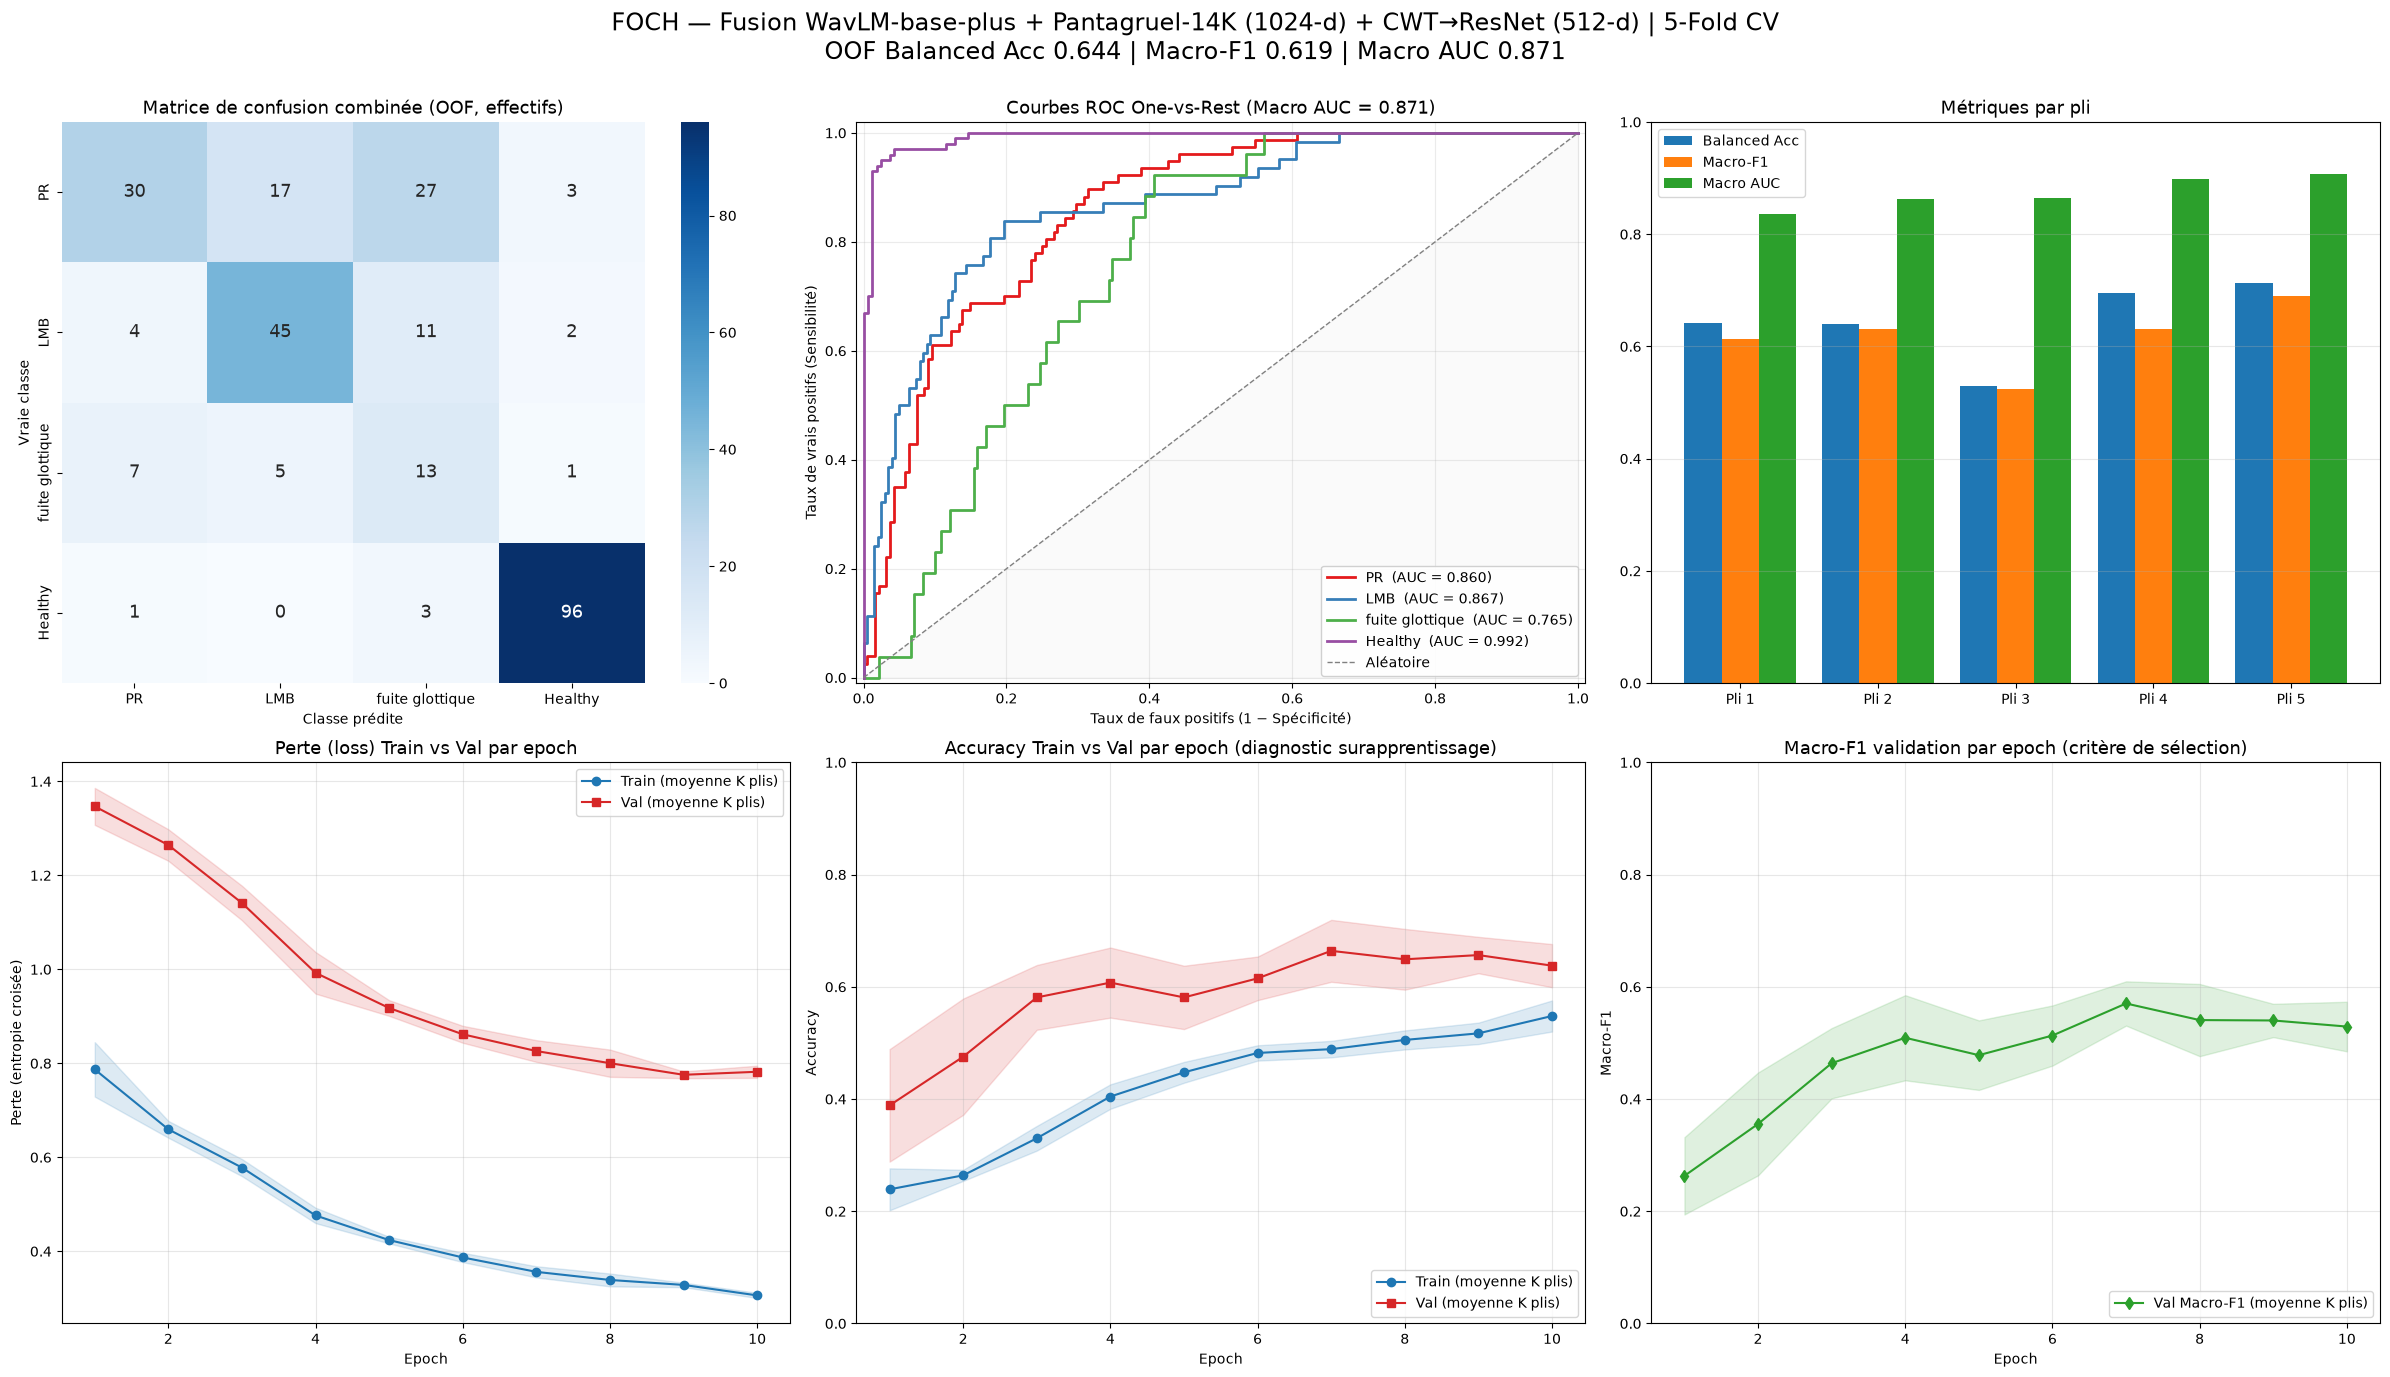


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • pantagruel_wavlm_bp_cwt_resnet_kfold_aug_dashboard.png
  • pantagruel_wavlm_bp_cwt_resnet_kfold_aug_metrics.json
  • pantagruel_wavlm_bp_cwt_resnet_kfold_aug_confusion.csv
  • pantagruel_wavlm_bp_cwt_resnet_kfold_aug_fold_metrics.csv


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset réellement actif ──────────────────────
_arch_names = []
if WAVLM_VARIANT:   _arch_names.append(f'WavLM-{WAVLM_VARIANT.replace("_", "-")}')
if USE_PANTAGRUEL:  _arch_names.append(f'Pantagruel-14K ({PANTAGRUEL_EMB_DIM}-d)')
if USE_RESIDUAL:    _arch_names.append(f'Résidu-Vocos×{N_RESIDUAL_FEATURES}→{RESIDUAL_PROJ_DIM}')
if USE_CWT_CNN:     _arch_names.append(f'CWT→ResNet ({RESNET_EMB_DIM}-d)')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Tableau de bord 2×3 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

# ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────────
assert 'fold_train_loss' in globals() and len(fold_train_loss), \
    "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep_loss = min(min(len(h) for h in fold_train_loss),
                   min(len(h) for h in fold_curves))
tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])   # (K, min_ep)
va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
ep_loss = np.arange(1, min_ep_loss + 1)
axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Perte (entropie croisée)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─────
assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
        and len(fold_train_acc) and len(fold_val_acc), \
    "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep = min(min(len(h) for h in fold_train_acc),
             min(len(h) for h in fold_val_acc))
tr = np.array([h[:min_ep] for h in fold_train_acc])   # (K, min_ep)
va = np.array([h[:min_ep] for h in fold_val_acc])
ep = np.arange(1, min_ep + 1)
axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# ── [1, 2] Macro-F1 de validation par epoch (critère de sélection) ────────────
# C'est la métrique qui pilote checkpoint et arrêt anticipé (Cellule 7) : la
# tracer explicite ce que l'entraînement a réellement optimisé.
min_ep_f1 = min(len(h) for h in fold_val_f1)
vf1 = np.array([h[:min_ep_f1] for h in fold_val_f1])
ep_f1 = np.arange(1, min_ep_f1 + 1)
axes[1, 2].plot(ep_f1, vf1.mean(0), 'd-', color='#2ca02c', label='Val Macro-F1 (moyenne K plis)')
axes[1, 2].fill_between(ep_f1, vf1.mean(0) - vf1.std(0), vf1.mean(0) + vf1.std(0),
                        color='#2ca02c', alpha=0.15)
axes[1, 2].set_title('Macro-F1 validation par epoch (critère de sélection)', fontsize=13)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Macro-F1')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend(loc='lower right')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'preset':                 BACKBONE,
    'branches':               {'wavlm': WAVLM_VARIANT, 'pantagruel': USE_PANTAGRUEL, 'residual': USE_RESIDUAL, 'cwt_cnn': USE_CWT_CNN},
    'fusion_dim':             int(FUSION_DIM_EXPECTED),
    'pantagruel_emb_dim':     int(PANTAGRUEL_EMB_DIM),
    'resnet_variant':         RESNET_VARIANT if USE_CWT_CNN else None,
    'resnet_emb_dim':         int(RESNET_EMB_DIM) if USE_CWT_CNN else 0,
    'cwt_wavelet':            CWT_WAVELET if USE_CWT_CNN else None,
    'cwt_freq_range_hz':      [CWT_FREQ_MIN, CWT_FREQ_MAX] if USE_CWT_CNN else None,
    'encoders_frozen':        True,
    'residual_features':      list(RESIDUAL_FEATURES) if USE_RESIDUAL else [],
    'residual_proj_dim':      RESIDUAL_PROJ_DIM if USE_RESIDUAL else 0,
    # Statistiques de résidu PAR PLI : leur variation d'un pli à l'autre atteste
    # qu'elles sont calculées sur le seul train, et non globalement.
    'residual_stats_per_fold': fold_residual_stats,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')

## 9. Synthèse et prochaines étapes

**Ce que fait ce notebook.**

- **Classifieur quadri-branche configurable**, protocole d'évaluation inchangé depuis `10_0_foch_test_pantagruel.ipynb` / `11_0_foch_test_cwt_dinov2.ipynb`.
- **Préset par défaut : `wavlm_bp_cwt_resnet`** — WavLM Base-Plus + scalogramme CWT → ResNet, sans Pantagruel ni résidu vocodeur. Tous les presets à trois et quatre branches restent disponibles.
- **Branche D — CWT → ResNet, remplace la variante Vision Transformer (DINOv2-Large) de `11_0_foch_test_cwt_dinov2.ipynb`.** Même position architecturale (scalogramme → backbone pré-entraîné sur images naturelles, gelé, concaténé sans projection apprise), pari différent : convolutif/local (ResNet, poids ImageNet torchvision) plutôt qu'attentionnel/global (ViT, DINOv2). `RESNET_VARIANT` (défaut `resnet50`) est configurable sans toucher aucune autre cellule.
- **Résolution de dimension à l'exécution, systématique** : `RESNET_EMB_DIM` (`.fc.in_features`) et `RESNET_IMG_SIZE` (`weights.transforms().crop_size`) sont lues depuis l'architecture/les métadonnées torchvision, puis **revérifiées sur une passe avant réelle** en Cellule 6 — même discipline que Pantagruel et que la variante DINOv2 avant elle.
- **Fine-tuning limité à la tête** : les trois encodeurs profonds sont intégralement gelés.
- **Validation croisée sans fuite**, inchangée. La branche scalogramme n'a pas de statistique de pli à recalculer (normalisation fixe, constantes ImageNet du checkpoint torchvision).

**Pistes d'amélioration ultérieures :**
1. **Comparer directement aux presets équivalents de `11_0_foch_test_cwt_dinov2.ipynb`** (`wavlm_bp_cwt_vit` vs `wavlm_bp_cwt_resnet`, même graine, mêmes plis) — c'est la mesure directe de l'hypothèse local/convolutif vs global/attentionnel posée en Cellule 1, actuellement non tranchée.
2. **Exécuter la grille d'ablation propre à ce notebook** (`wavlm_bp_solo`, `cwt_resnet_solo`, `wavlm_bp_cwt_resnet`, puis les presets incluant Pantagruel/résidu) — même graine, mêmes plis.
3. **Comparer les trois variantes de `RESNET_VARIANT`** (18/34/50) — seul `resnet50` a été retenu par défaut, sans comparaison empirique sur ce corpus. Les variantes 18/34 (512-d) pourraient mieux résister au surapprentissage de la tête de fusion sur ~300 échantillons, à dimension de fusion plus faible.
4. **Comparer le choix de colormap** (`CWT_COLORMAP`, `viridis`) à une réplication en niveaux de gris ×3 — question ouverte héritée de la variante ViT, toujours pas tranchée ici.
5. **Ré-évaluer la bande de fréquences CWT** (50-7500 Hz) — reprise telle quelle de la variante ViT, pas ajustée aux pathologies FOCH spécifiquement.
6. **Fine-tuning partiel du ResNet** (dégel des derniers blocs uniquement) une fois la branche validée en gelé — un ResNet est en général moins coûteux à dégeler partiellement qu'un ViT (moins de paramètres dans ses dernières couches), mais reste hors de portée avec ~300 échantillons pour l'instant.
7. **Vérifier la robustesse du téléchargement torchvision** sur la machine de production (RTX PRO 2000 portable) — testé uniquement en développement ici ; si `download.pytorch.org` est bloqué par le même pare-feu que `huggingface.co`, prévoir de déposer le `.pth` manuellement (message d'erreur explicite déjà en place, cf. Cellule 6).
8. **Mise en cache disque des embeddings gelés** — le ResNet étant figé, ses sorties sont constantes d'une époque à l'autre ; les précalculer une fois supprimerait l'essentiel du coût de chaque exécution (idée déjà notée dans les deux notebooks précédents, moins pressante ici que pour DINOv2-Large, mais toujours valable).
9. **Ensembling** des K modèles de plis à l'inférence.
10. **Audit qualité** des doublons d'homonymes (`Last_Name`) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8, plus 4b et 4c). WavLM, Pantagruel et Vocos sont chargés **localement** (`HF_HUB_OFFLINE=1`). La branche ResNet passe par **torchvision** : son premier chargement peut nécessiter un accès réseau à `download.pytorch.org` (cf. Cellule 1/6 pour le repli manuel si bloqué). La branche CWT requiert `pywt`. La Cellule 7 entraîne **K = 5 modèles** — budget VRAM sensiblement plus léger que `11_0_foch_test_cwt_dinov2.ipynb` grâce au ResNet (cf. Cellule 6b).

## Journal des modifications

- **2026-08-04 — Remplacement de la branche D : Vision Transformer (DINOv2-Large) → réseau convolutif (ResNet, poids ImageNet torchvision), preset par défaut renommé `wavlm_bp_cwt_resnet`.**
  - **Pourquoi** : tester un biais architectural différent pour la même idée de branche (scalogramme → backbone image pré-entraîné, gelé). Un ResNet construit sa représentation par convolutions locales empilées ; un ViT applique une attention globale dès sa première couche. Aucune des deux hypothèses n'était a priori supérieure pour des motifs pathologiques dans un scalogramme — ce notebook permet la comparaison directe avec `11_0_foch_test_cwt_dinov2.ipynb`, même protocole d'évaluation.
  - **Chargement via torchvision, pas HuggingFace** : contrairement à toutes les autres branches de ce notebook (WavLM, Pantagruel, DINOv2 dans la variante précédente), le ResNet n'est pas chargé depuis un répertoire local HuggingFace mais construit directement via `torchvision.models`, avec un cache géré par `TORCH_HOME` (Cellule 1) — domaine réseau différent (`download.pytorch.org` vs `huggingface.co`), statut de blocage **non vérifié** sur cette machine à la date d'écriture. Message d'erreur explicite et repli manuel documentés en Cellule 6, sur le même principe que le contournement Vocos (git clone + git lfs pull).
  - **`RESNET_VARIANT` configurable** (`resnet18` / `resnet34` / `resnet50`, défaut `resnet50`) : choix raisonné (dimension de sortie plus riche que 18/34, tout en restant ~12× plus léger que DINOv2-Large), **non comparé empiriquement** sur ce corpus — cf. pistes d'amélioration ci-dessus. Changer la variante ne nécessite de modifier aucune autre cellule.
  - **Dimension et taille d'image résolues différemment de la variante ViT, mais avec la même discipline** : `RESNET_EMB_DIM` vient de `.fc.in_features` (lu sans télécharger de poids, `weights=None`) plutôt que d'un `AutoConfig` HuggingFace ; `RESNET_IMG_SIZE` et les statistiques de normalisation viennent de `weights.transforms()` plutôt que d'un `AutoImageProcessor`. Le principe reste identique : rien n'est écrit en dur, tout est revérifié sur une passe avant réelle en Cellule 6.
  - **Retrait de la tête de classification (`fc = nn.Identity()`) plutôt qu'extraction d'un jeton** : un ResNet ImageNet standard se termine par pooling global + `fc` (1000 classes) — retirer `fc` expose directement le vecteur pooled, sans slicing équivalent au jeton `[CLS]` de DINOv2. Toujours aucune projection apprise sur cette branche (comme la variante ViT, à la différence de la branche C).
  - **CWT, cache, et logique de fusion inchangés** : le calcul du scalogramme (Cellule 4), son cache (`SCALOGRAM_CACHE_ENABLED`), la signature `forward(..., scalogram)` et la boucle K-Fold (Cellule 7) sont restés **structurellement identiques** à `11_0_foch_test_cwt_dinov2.ipynb` — seule la source des statistiques de normalisation de l'image et le backbone lui-même ont changé.
  - **Renommage systématique** `USE_CWT_VIT`→`USE_CWT_CNN`, `DINOV2_DIR/DINOV2_EMB_DIM/DINOV2_IMG_SIZE`→(retiré)/`RESNET_EMB_DIM`/`RESNET_IMG_SIZE`, presets `*_cwt_vit`→`*_cwt_resnet`, `self.dinov2`→`self.resnet` (donc **nouveau** `RUN_NAME` par preset — aucun écrasement des checkpoints/métriques de `11_0_foch_test_cwt_dinov2.ipynb`).
  - **Cellule 4c, Cellule 6b, boucle K-Fold (Cellule 7) et évaluation (Cellule 8)** : structure inchangée, mentions de branche mises à jour.

  **Questions ouvertes (nouvelles, spécifiques à cette variante) :**
  - **ResNet vs ViT non comparé empiriquement sur ce corpus** — c'est la question de fond que ce notebook pose sans y répondre ; cf. piste d'amélioration n°1.
  - **Profondeur ResNet (18/34/50) non comparée** — cf. piste d'amélioration n°3.
  - **Accès réseau à `download.pytorch.org` non vérifié** sur la machine de production — seule la classe de restriction connue (`huggingface.co` bloqué) est documentée ; à vérifier avant la première exécution en conditions réelles.
  - **Valeur clinique réelle non établie**, comme pour la variante ViT — cette branche reste une hypothèse indirecte (aucun a priori de parole dans le pré-entraînement ImageNet).
